# How Data Constrains the Model

The central question of SED fitting: **how much data do you need to
constrain a galaxy's star formation history?**

We take a single mock galaxy with a known bursty SFH and fit it with
progressively richer data — from a single photometric band to a
200-pixel spectrum.  At each step we show the posterior and recovered
SFH, watching the constraints sharpen in real time.

This is the "why this method matters" notebook.

In [1]:
import time

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

import sys; sys.path.insert(0, ".")
from _plot_style import setup_style, COLORS, SDSS_WAVE_EFF, safe_corner
setup_style()

from diffsed import (
    Model, ParamSpec, Uniform, Fixed, Fitter,
    load_ssp_data, load_filter_set,
)

ssp_data = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# Load SDSS ugriz (5 bands)
filters_sdss = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

# Also load GALEX NUV for UV leverage demonstration
filters_galex = load_filter_set(["galex_nuv"])

print("SSP data and filters loaded.")

SSP data and filters loaded.


## The Experiment

We fit the **same galaxy** with increasingly rich data:

| Stage | Data | Bands / pixels |
|-------|------|----------------|
| 1 | r-band only | 1 |
| 2 | g, r, i | 3 |
| 3 | SDSS ugriz | 5 |
| 4 | ugriz + GALEX NUV | 6 |
| 5 | 200-pixel spectrum | 200 |

At each step we show: **(1)** the data being used, **(2)** the posterior
on key physical parameters, **(3)** the recovered SFH.

In [2]:
# Stochastic model with full SDSS filters — our ground truth
spec_full = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0), sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0), sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Uniform(0.1, 4.0), psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0), dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7), redshift=Fixed(0.1),
    stochastic=True, n_grid=128,
)
model_full = Model(spec_full, ssp_data, filters=filters_sdss)

key = jax.random.PRNGKey(42)
true_params = spec_full.sample(key)
mock_full = model_full.mock(true_params, snr=20.0, key=key)

print(f"Free parameters: {spec_full.n_free}")
print(f"True PSD sigma:   {true_params['psd_sigma']:.2f}")
print(f"True PSD tau_myr: {true_params['psd_tau_myr']:.1f}")

W0315 10:50:29.726167 4813774 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Free parameters: 9
True PSD sigma:   0.17
True PSD tau_myr: 134.6


In [3]:
# Color palette: each stage gets progressively darker/richer color
STAGE_COLORS = {
    "1 band":   "C7",   # grey — almost no information
    "3 bands":  "C9",   # cyan
    "5 bands":  "C0",   # blue — standard photometry
    "6 bands":  "C2",   # green — UV added
    "spectrum": "C3",   # red — dramatic leap
}

def run_fit(model, flux_obs, noise, label, data_type="photometry", **kw):
    """Run MAP + Ray Tracing and return the result dict."""
    fitter = Fitter(model, flux_obs, noise, data_type=data_type, **kw)

    t0 = time.perf_counter()
    result_map = fitter.run("map", n_steps=1000)
    result_rt = fitter.run("raytrace", init_from=result_map,
                           n_burnin=100, n_steps=300, step_size=0.01)
    elapsed = time.perf_counter() - t0

    print(f"{label}: fit completed in {elapsed:.1f}s")
    return result_rt

## One Photometric Band (r-band only)

With a single flux measurement we know almost nothing — the posterior
should be close to the prior.  One number cannot simultaneously
constrain age, metallicity, dust, and SFH shape.

  Step     0/1000: loss = 115.1893
  Step   200/1000: loss = 0.5094
  Step   400/1000: loss = 0.2932
  Step   600/1000: loss = 0.1506
  Step   800/1000: loss = 0.0605
  Step   999/1000: loss = 0.0179
  MAP (ADAM) complete in 0.3s, 1000 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 99.7% (overall), 99.7% (post burn-in). Samples: 300
1 band: fit completed in 1.4s


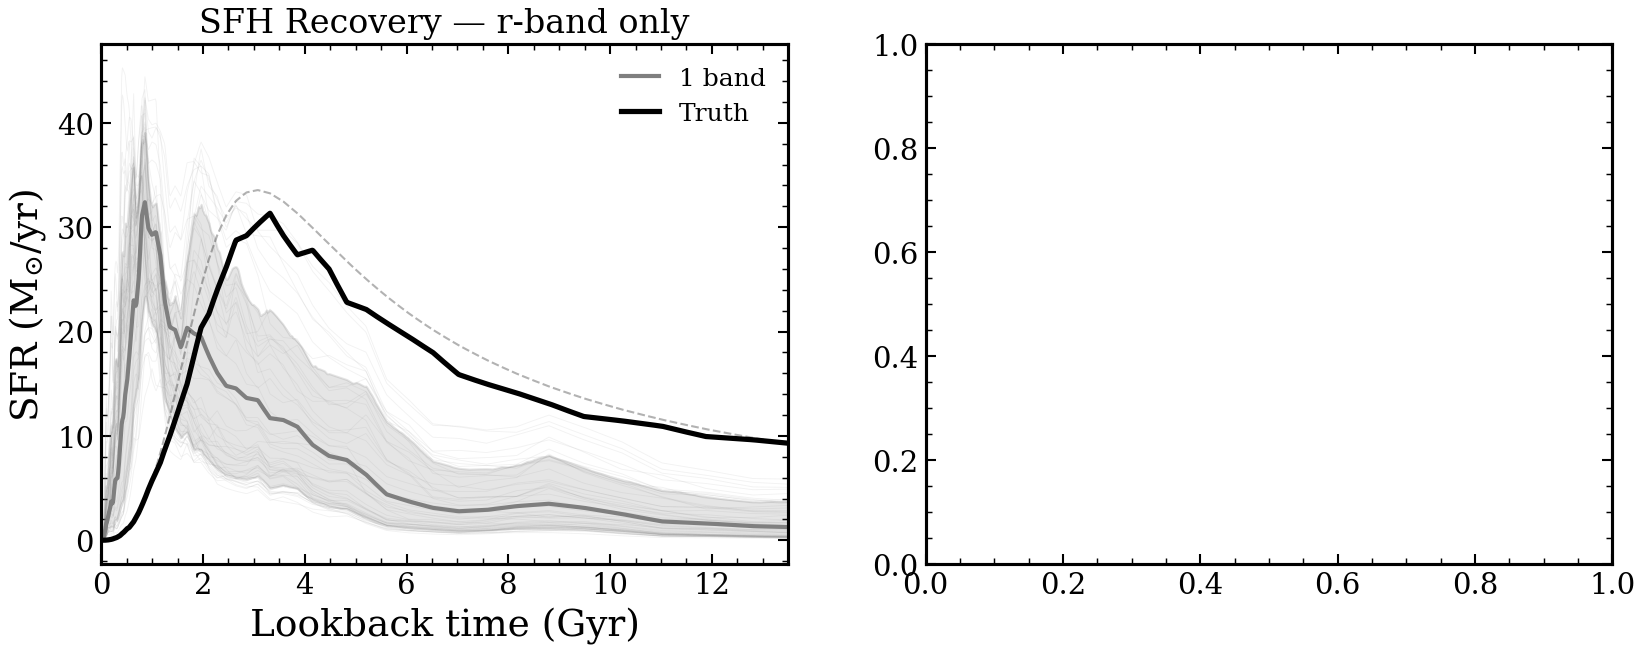

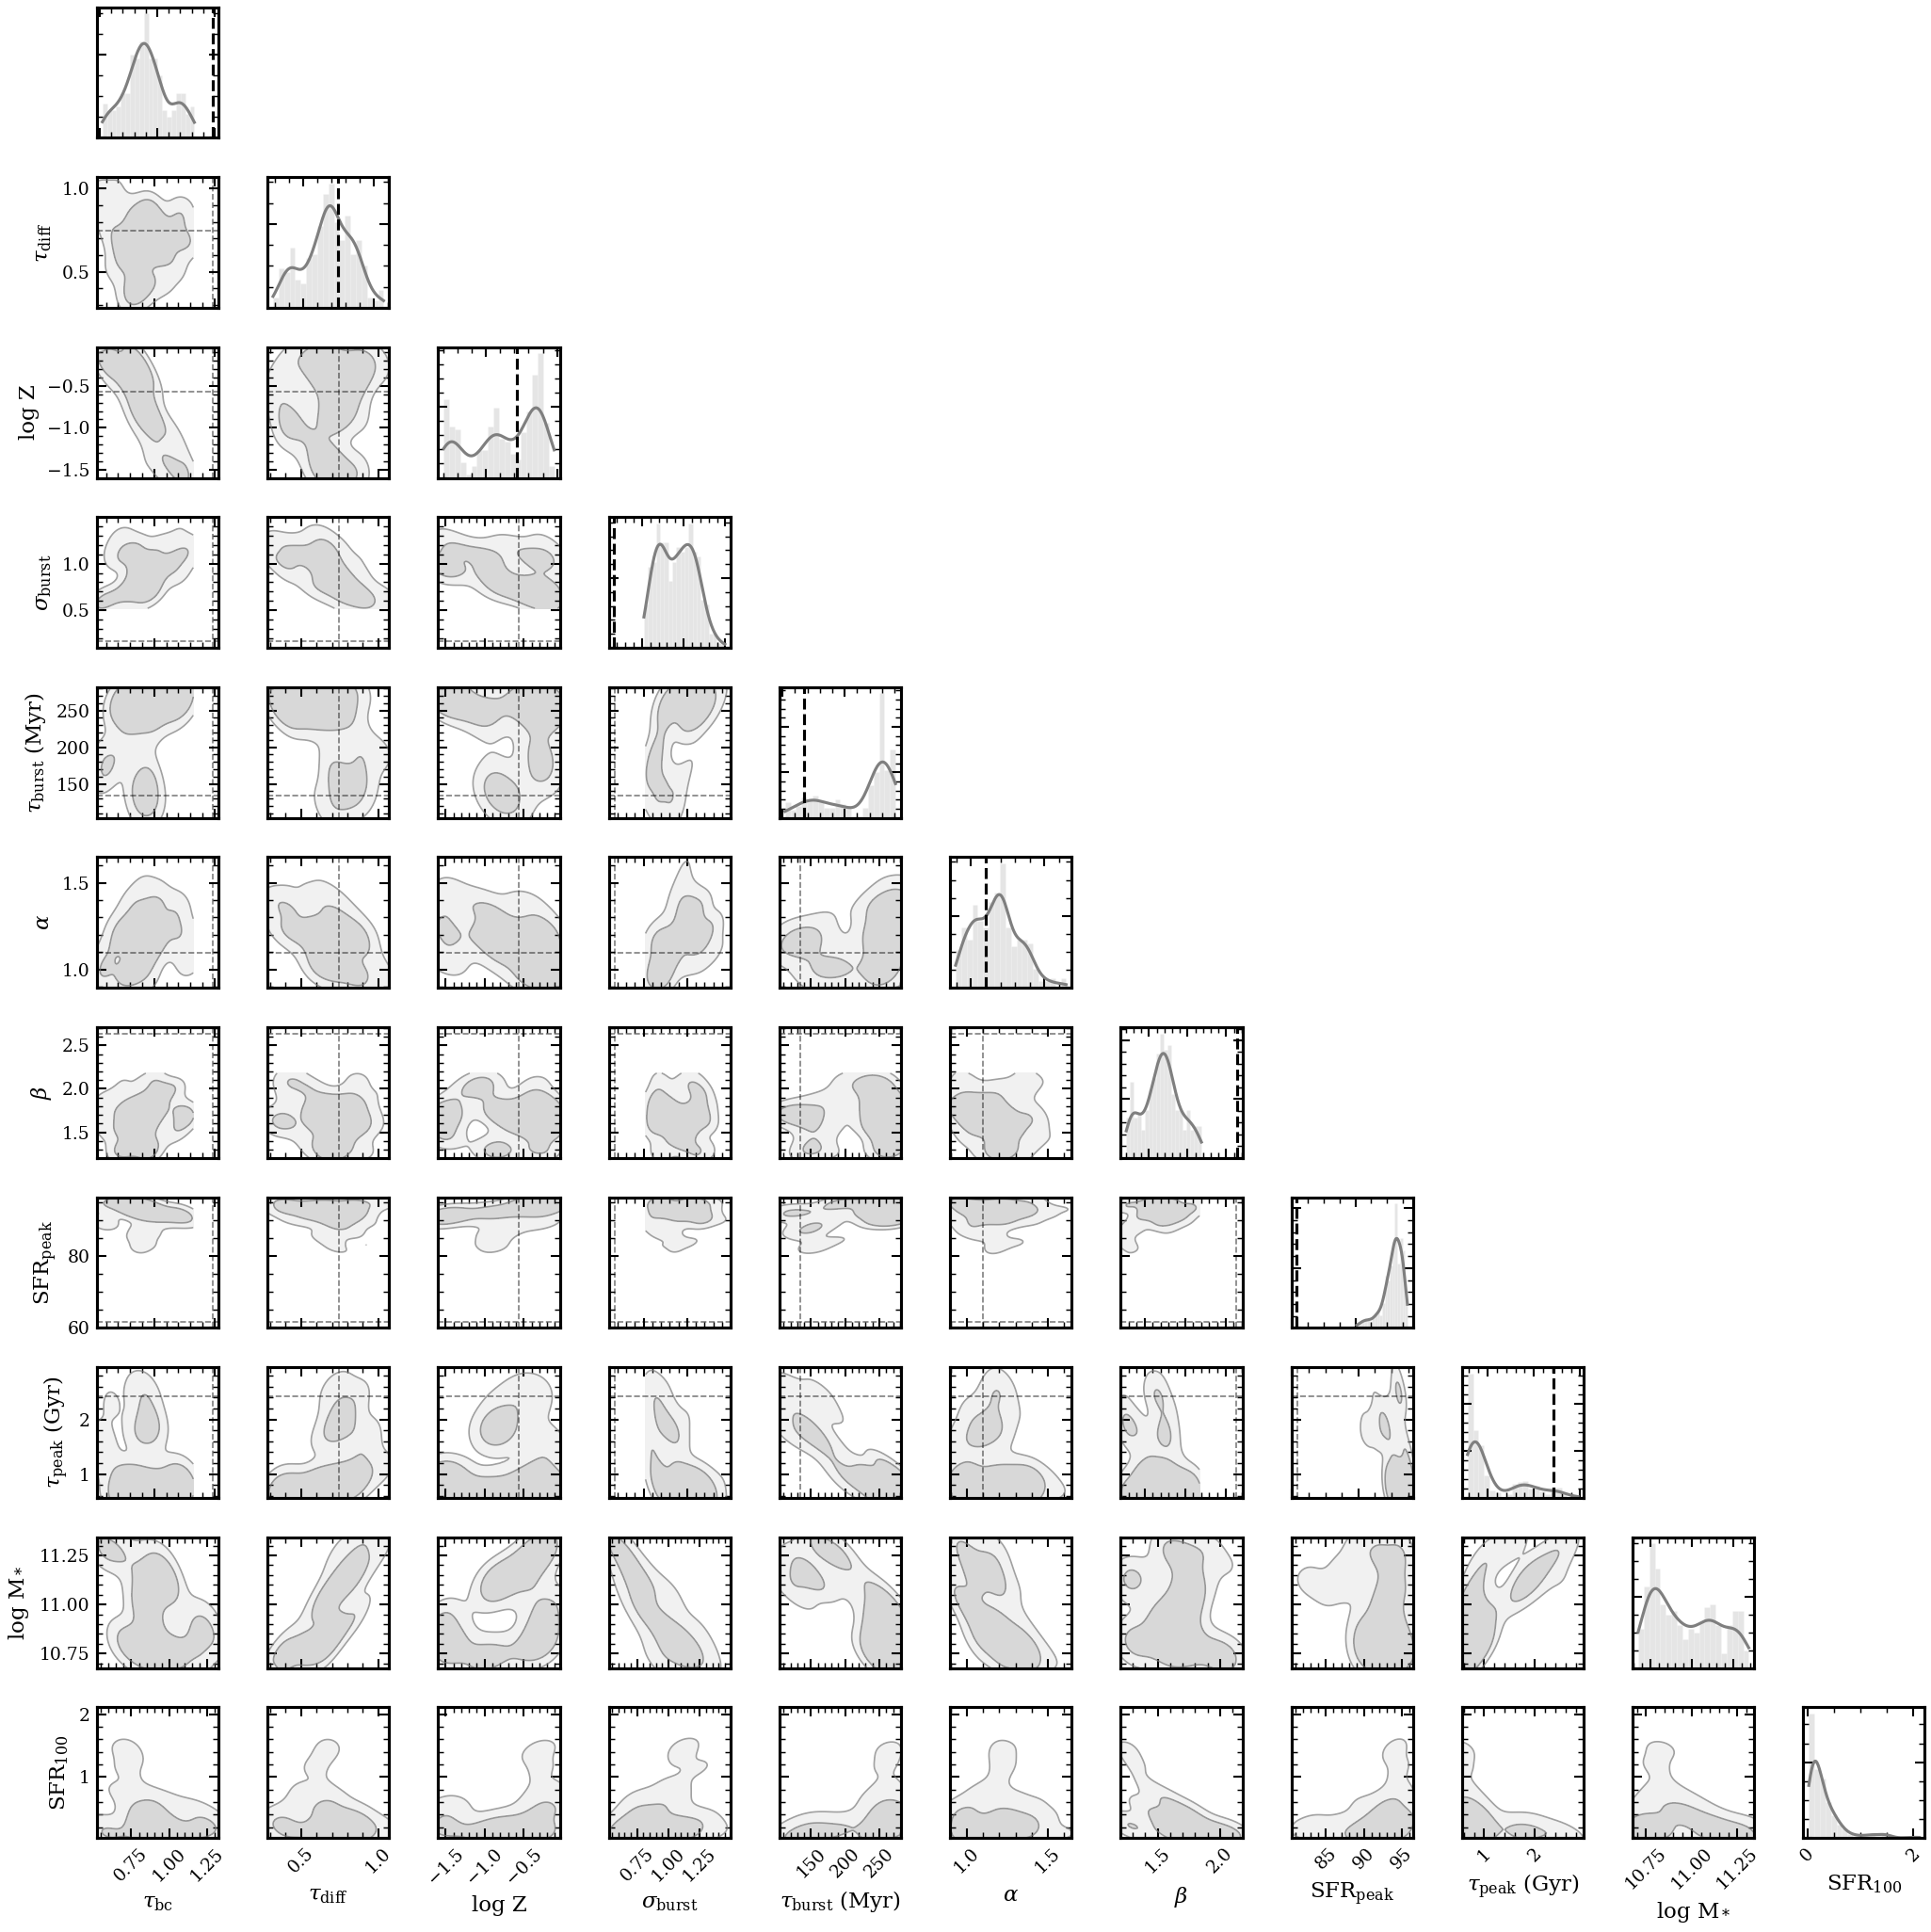

In [4]:
# Build a 1-band model (r-band only)
filters_r = load_filter_set(["sdss_r"])
model_1 = Model(spec_full, ssp_data, filters=filters_r)

# Extract the r-band mock data (index 2 in ugriz)
flux_1 = mock_full.flux_obs[2:3]
noise_1 = mock_full.noise[2:3]

result_1band = run_fit(model_1, flux_1, noise_1, "1 band")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# SFH recovery
model_1.plot_sfh_posterior(result_1band, true_params=true_params,
                          color=STAGE_COLORS["1 band"], label="1 band",
                          ax=axes[0])
axes[0].set_title("SFH Recovery — r-band only")
axes[0].legend()

# Corner plot
fig_corner_1 = safe_corner(result_1band, truths=true_params,
                           color=STAGE_COLORS["1 band"],
                           label="1 band")
plt.show()

## Three Bands (g, r, i)

Optical colors provide SED shape information.  Two colors (g-r, r-i)
can partially break the age-dust degeneracy, but significant freedom
remains.  The posterior begins to concentrate — but is still broad.

  Step     0/1000: loss = 320.1733
  Step   200/1000: loss = 0.9399
  Step   400/1000: loss = 0.7281
  Step   600/1000: loss = 0.6260
  Step   800/1000: loss = 0.5514
  Step   999/1000: loss = 0.4863
  MAP (ADAM) complete in 0.3s, 1000 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.3s. Acceptance: 99.5% (overall), 99.7% (post burn-in). Samples: 300
3 bands: fit completed in 0.8s


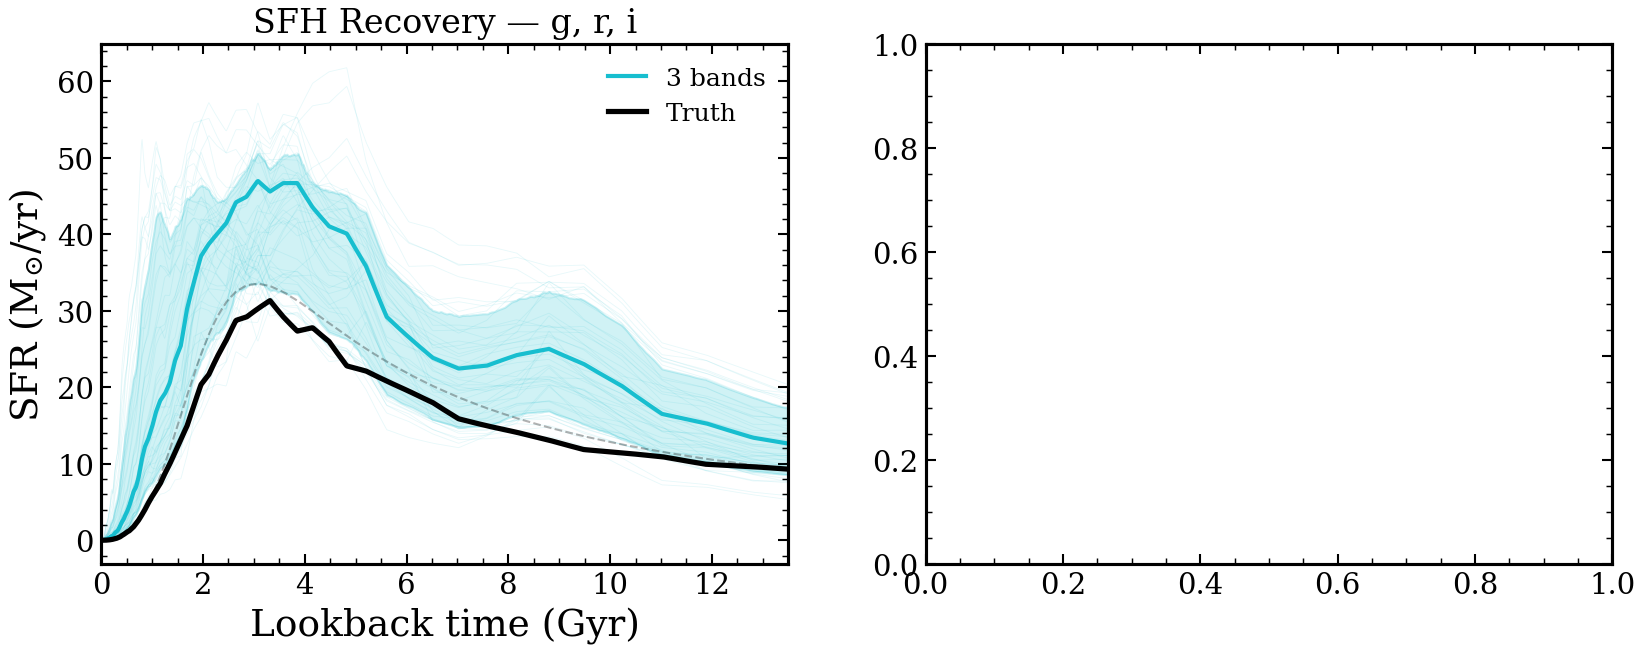

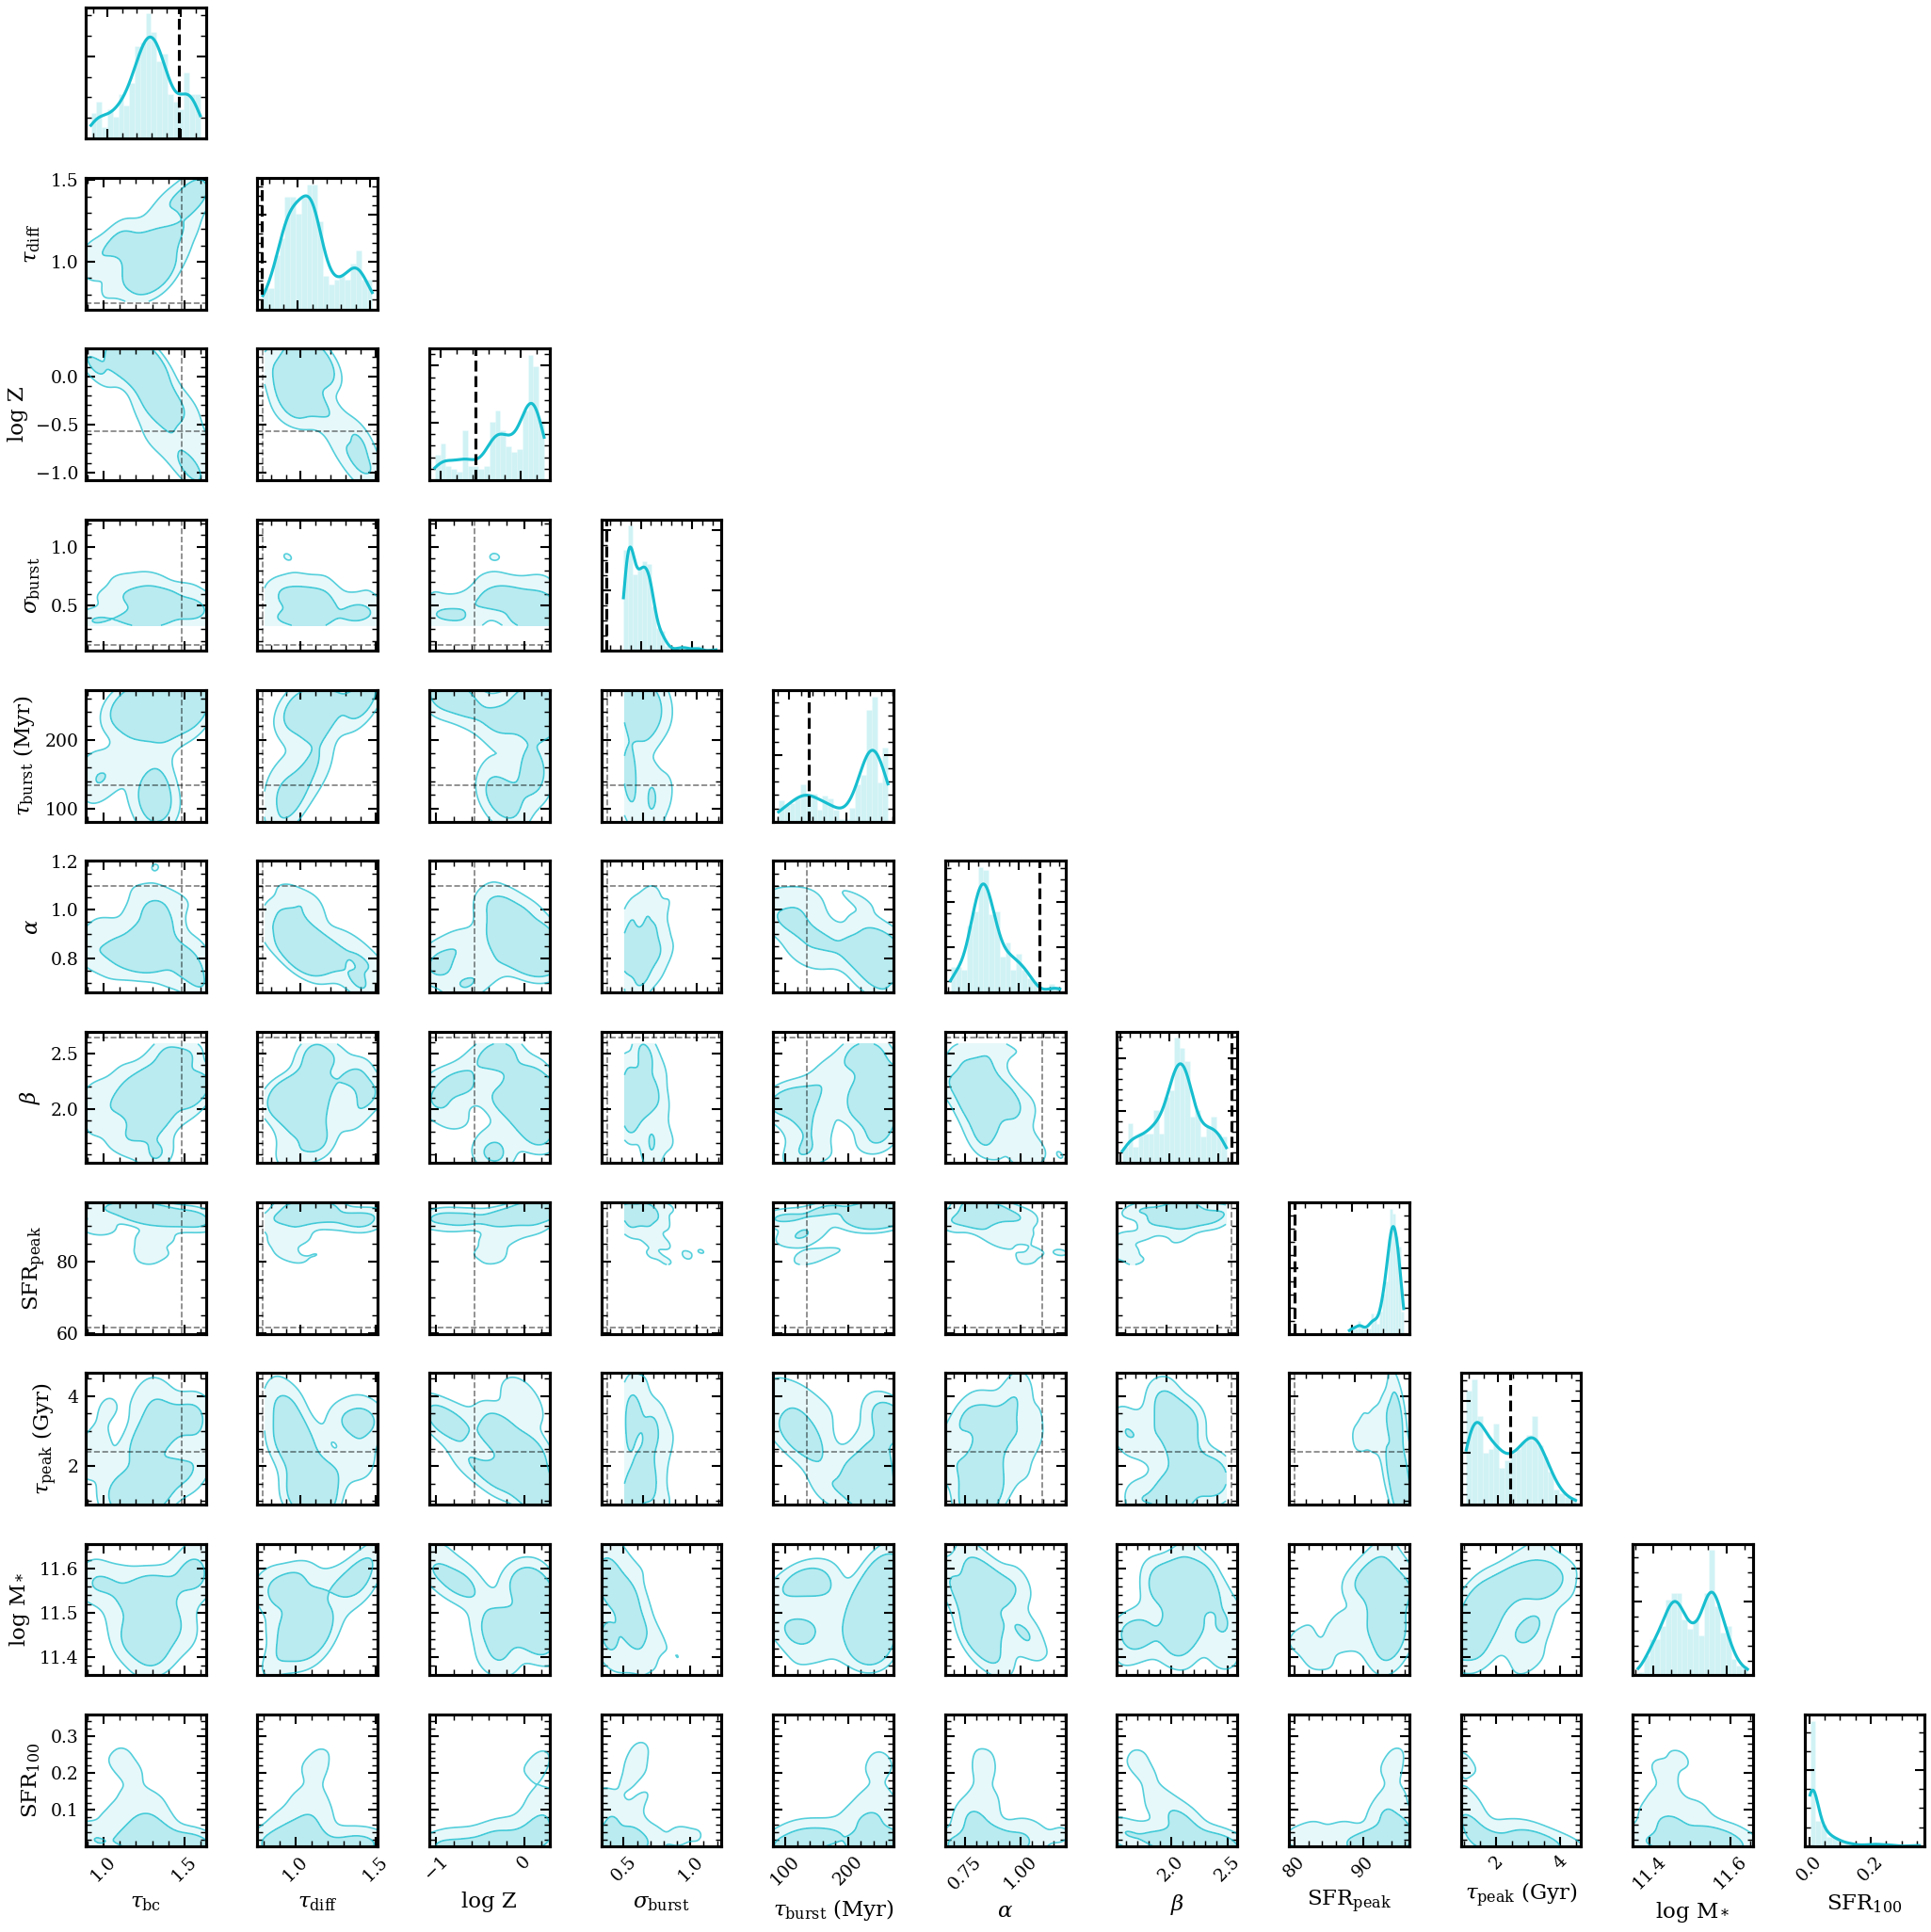

In [5]:
# Build a 3-band model (g, r, i)
filters_gri = load_filter_set(["sdss_g", "sdss_r", "sdss_i"])
model_3 = Model(spec_full, ssp_data, filters=filters_gri)

# Extract g, r, i from the full mock (indices 1, 2, 3 in ugriz)
idx_gri = jnp.array([1, 2, 3])
flux_3 = mock_full.flux_obs[idx_gri]
noise_3 = mock_full.noise[idx_gri]

result_3band = run_fit(model_3, flux_3, noise_3, "3 bands")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

model_3.plot_sfh_posterior(result_3band, true_params=true_params,
                          color=STAGE_COLORS["3 bands"], label="3 bands",
                          ax=axes[0])
axes[0].set_title("SFH Recovery — g, r, i")
axes[0].legend()

fig_corner_3 = safe_corner(result_3band, truths=true_params,
                           color=STAGE_COLORS["3 bands"],
                           label="3 bands")
plt.show()

## Five Bands (SDSS ugriz)

Standard photometric SED fitting.  The u-band constrains recent star
formation (UV excess from young O/B stars), while the z-band anchors
stellar mass via the older population.  This is the workhorse
configuration of large-survey SED fitting (CIGALE, BAGPIPES, Prospector).

  Step     0/1000: loss = 556.1412
  Step   200/1000: loss = 2.4339
  Step   400/1000: loss = 2.1764
  Step   600/1000: loss = 2.0067
  Step   800/1000: loss = 1.8727
  Step   999/1000: loss = 1.7699
  MAP (ADAM) complete in 0.3s, 1000 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 99.3% (overall), 99.4% (post burn-in). Samples: 300
5 bands: fit completed in 0.9s


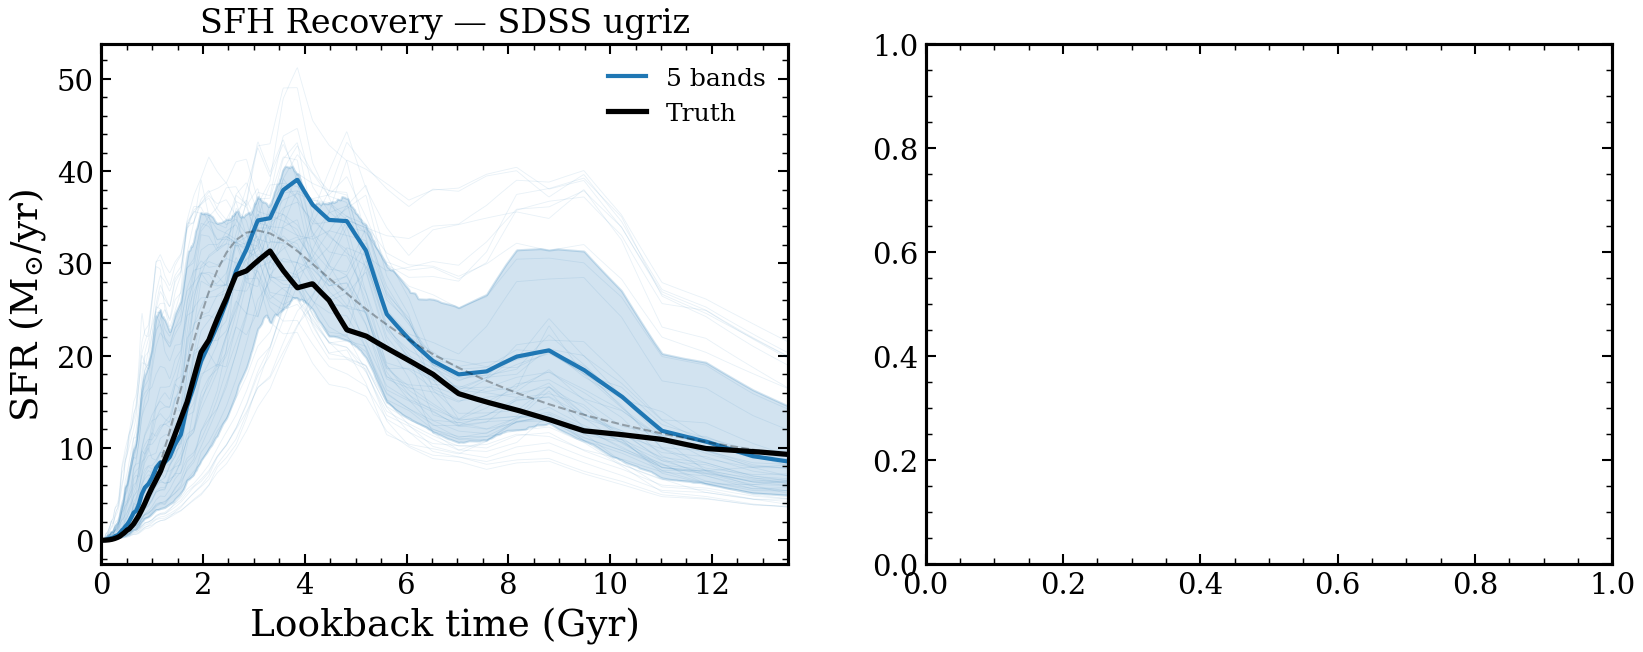

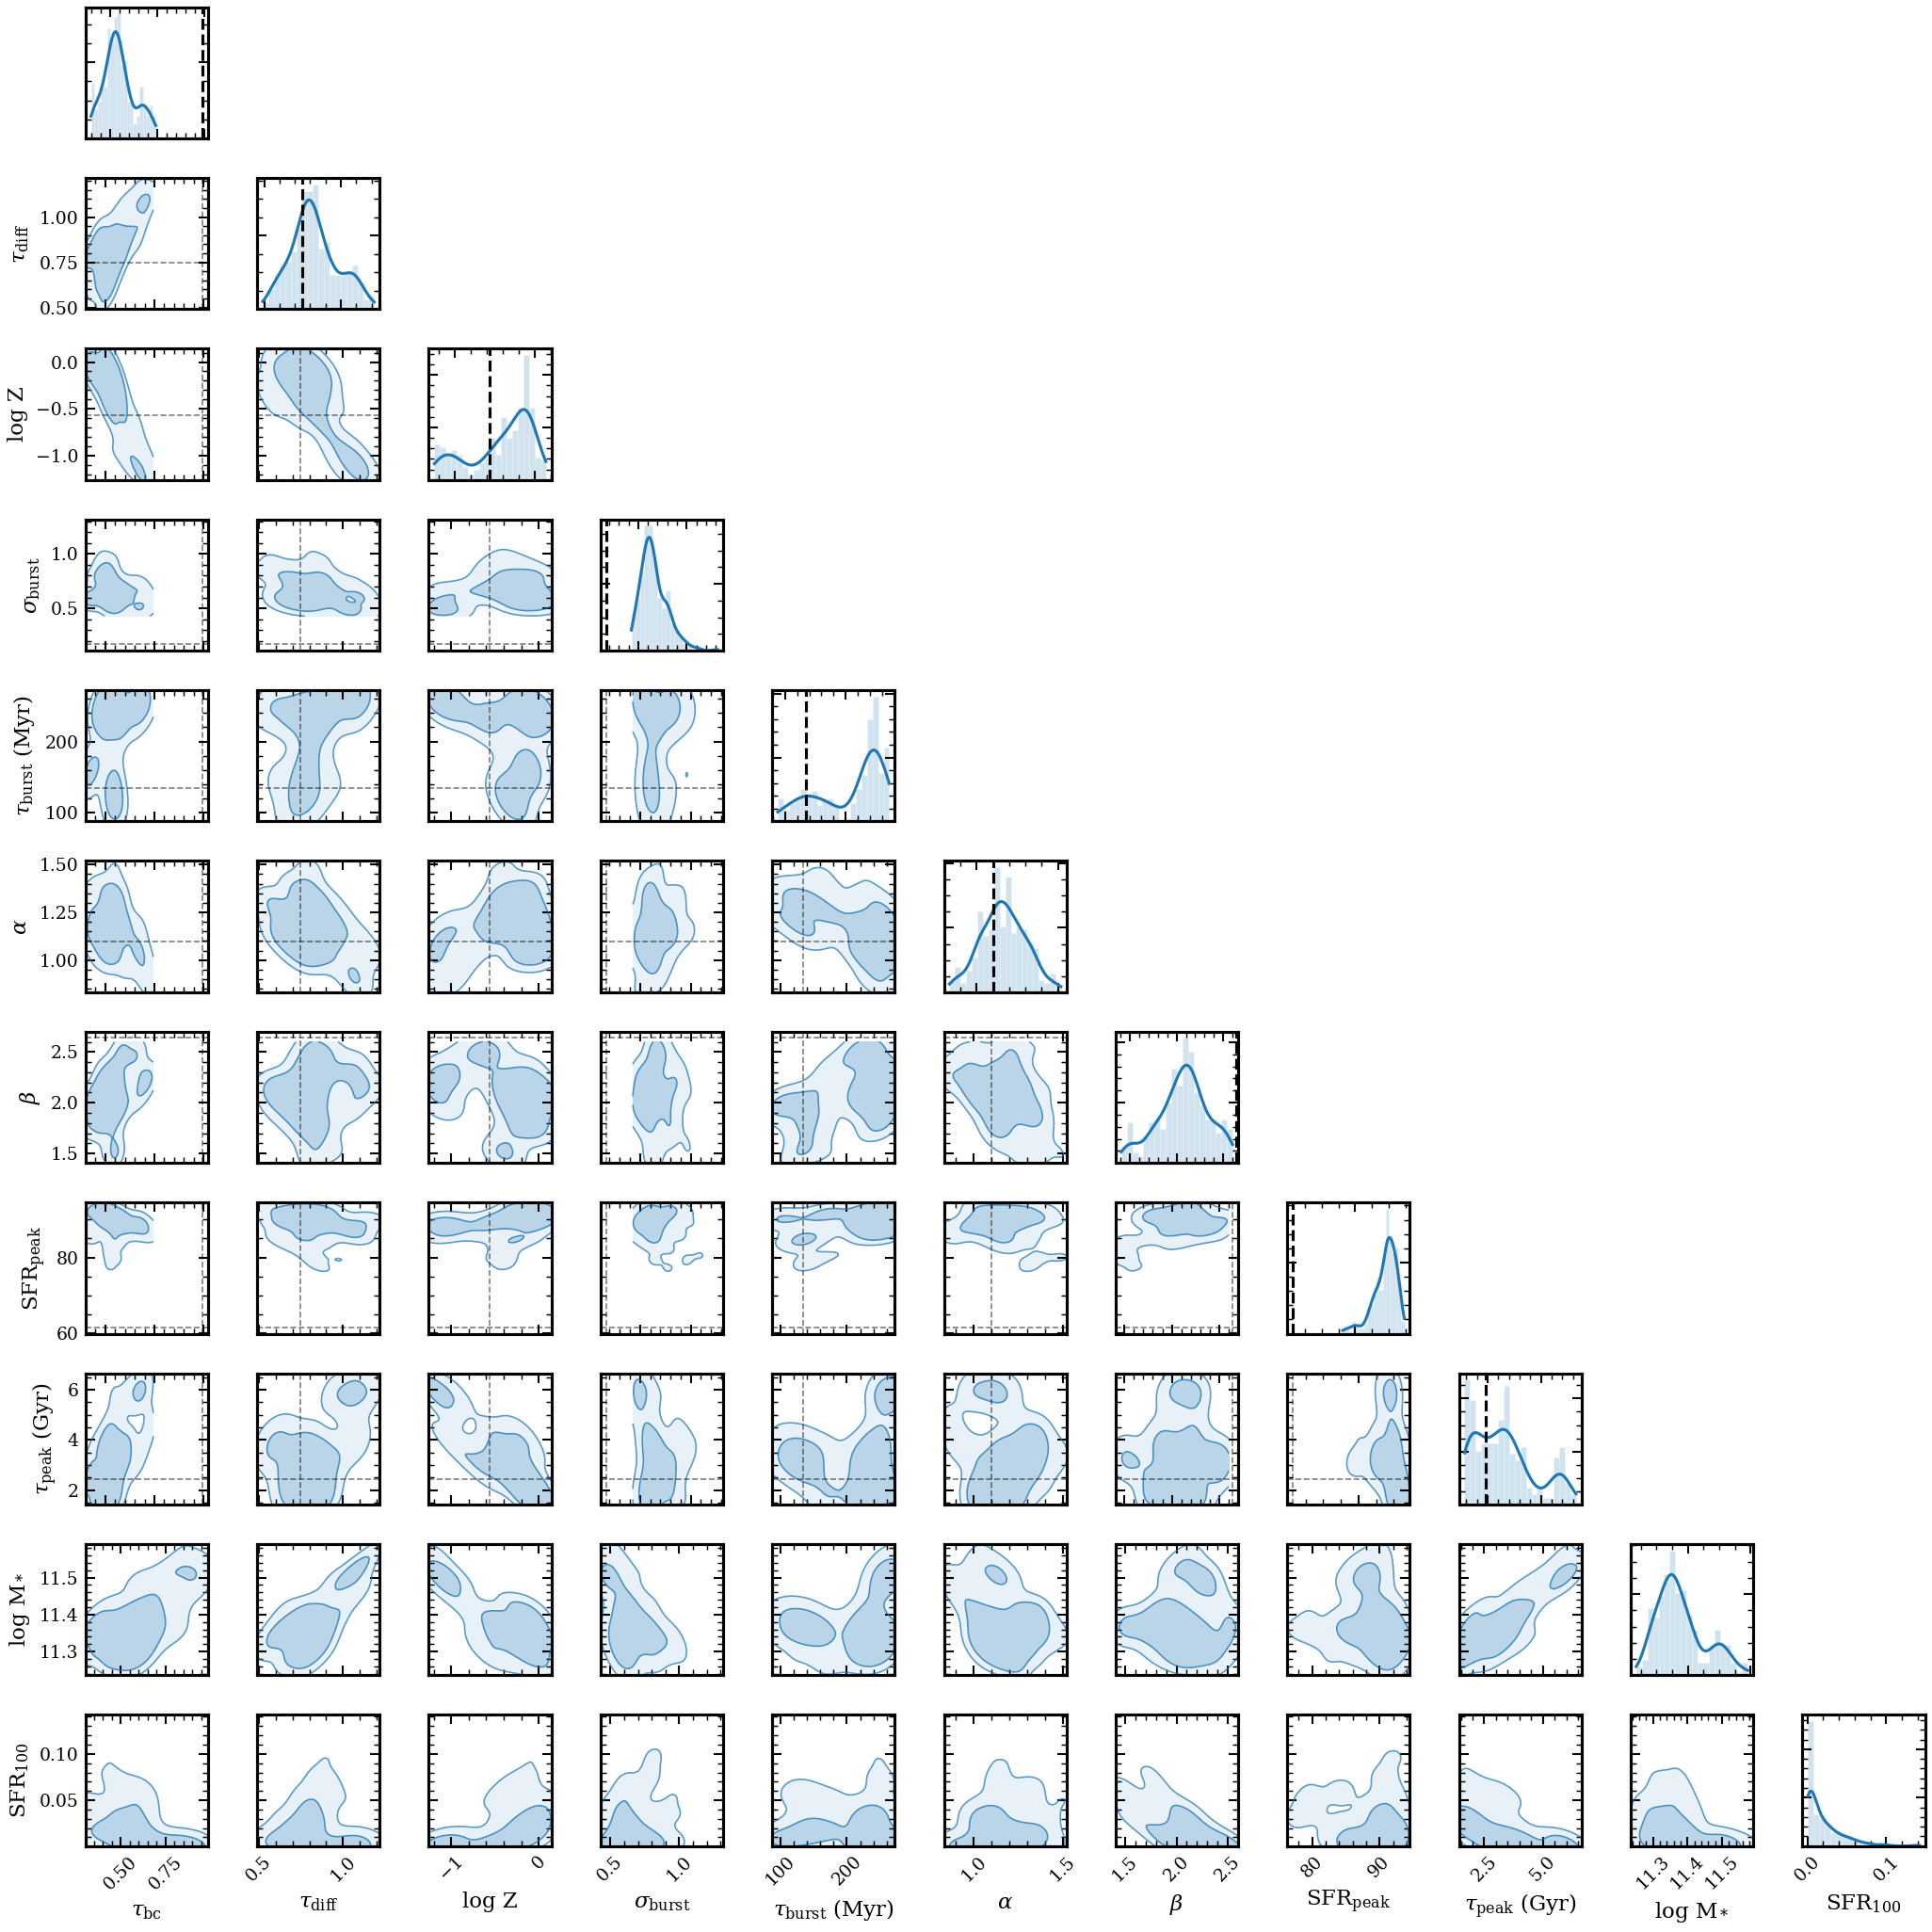

In [6]:
# Full SDSS ugriz
result_5band = run_fit(model_full, mock_full.flux_obs, mock_full.noise,
                       "5 bands")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

model_full.plot_sfh_posterior(result_5band, true_params=true_params,
                             color=STAGE_COLORS["5 bands"], label="5 bands",
                             ax=axes[0])
axes[0].set_title("SFH Recovery — SDSS ugriz")
axes[0].legend()

fig_corner_5 = safe_corner(result_5band, truths=true_params,
                           color=STAGE_COLORS["5 bands"],
                           label="5 bands")
plt.show()

## The Power of Wavelength Coverage

UV breaks the age-dust degeneracy: young stars produce UV flux that
dust preferentially absorbs.  NIR constrains stellar mass: old
populations dominate the K-band.  Adding either GALEX (UV) or
2MASS (NIR) to SDSS dramatically improves constraints.

We demonstrate by adding a single GALEX NUV point to the SDSS ugriz
photometry.

  Step     0/1000: loss = 703.9363
  Step   200/1000: loss = 2.4140
  Step   400/1000: loss = 1.8544
  Step   600/1000: loss = 1.5246
  Step   800/1000: loss = 1.3244
  Step   999/1000: loss = 1.2041
  MAP (ADAM) complete in 0.3s, 1000 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 98.7% (overall), 98.7% (post burn-in). Samples: 300
6 bands: fit completed in 0.9s


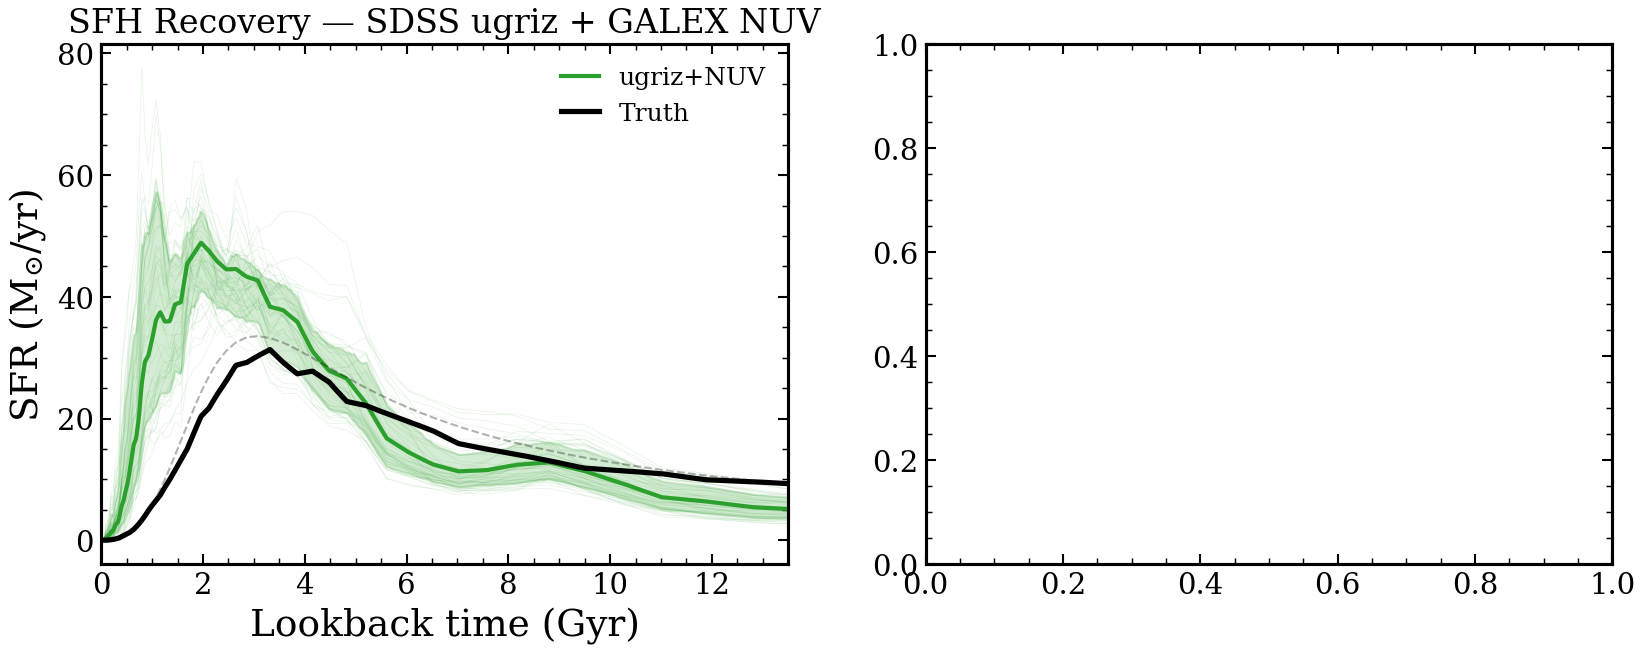

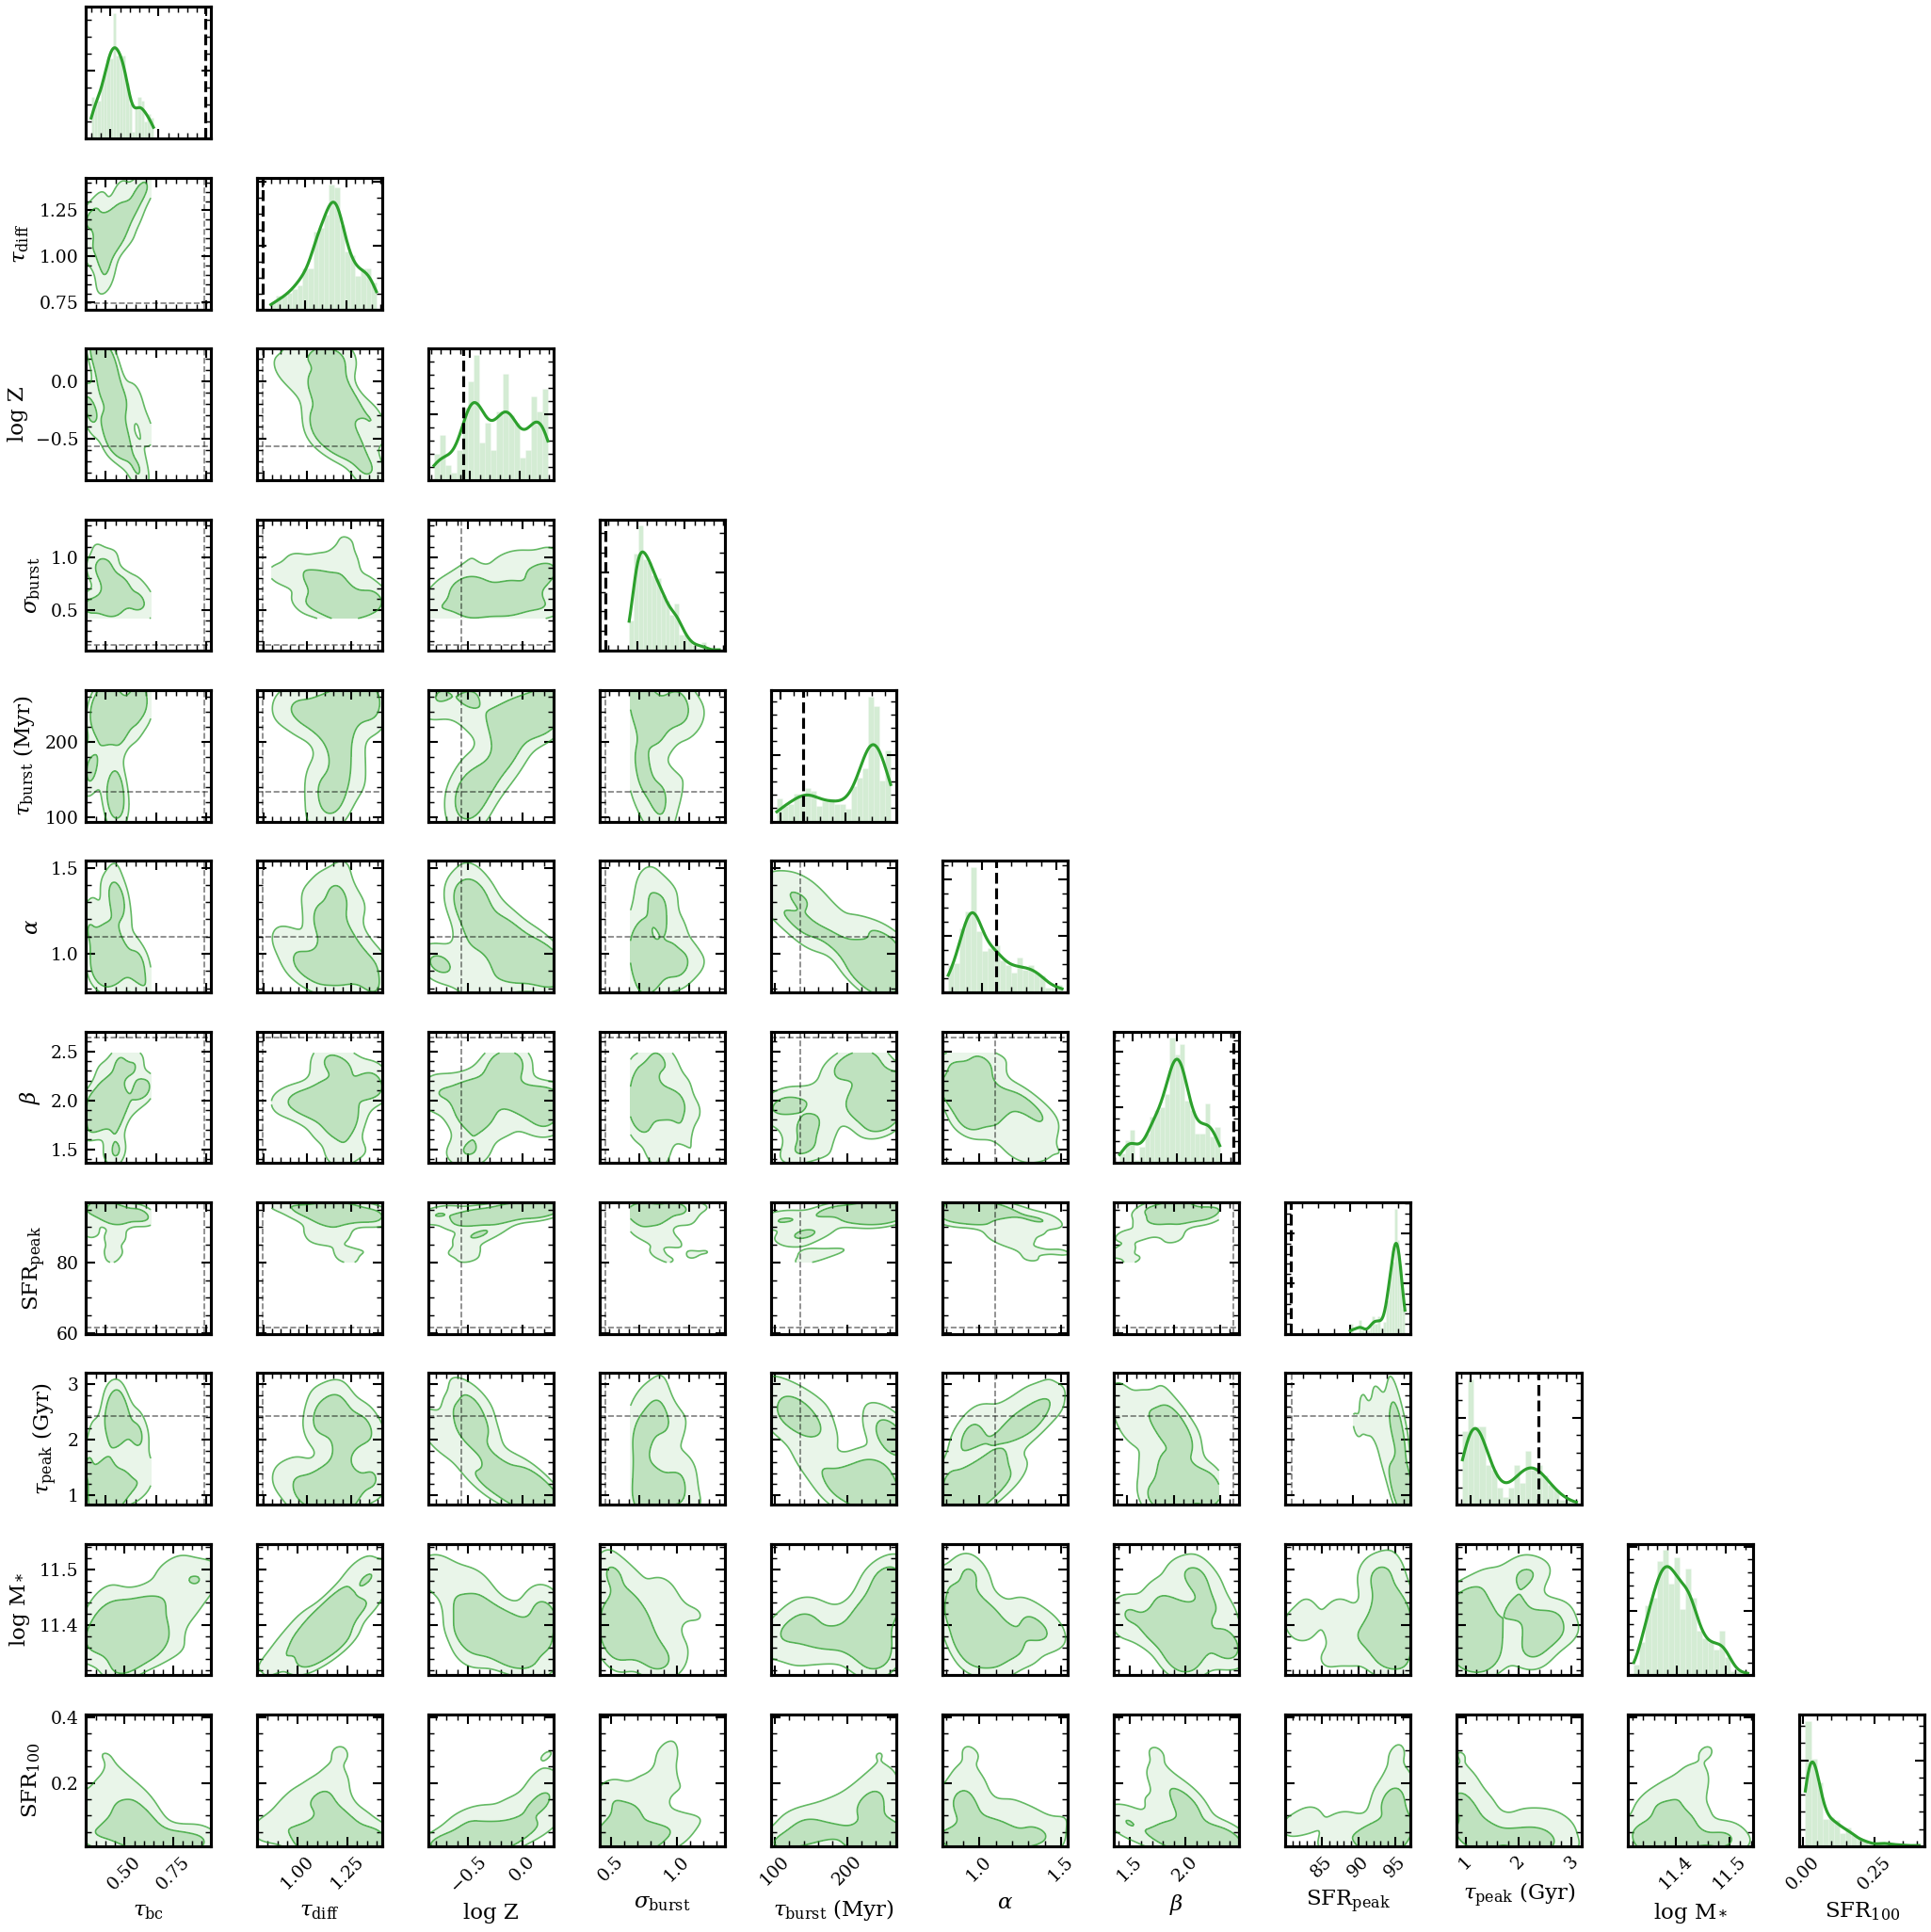

In [7]:
# Build 6-band model: SDSS ugriz + GALEX NUV
filters_6 = load_filter_set(
    ["galex_nuv", "sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]
)
model_6 = Model(spec_full, ssp_data, filters=filters_6)

# Generate the NUV mock flux using the same true parameters
mock_6 = model_6.mock(true_params, snr=20.0, key=key)

result_6band = run_fit(model_6, mock_6.flux_obs, mock_6.noise, "6 bands")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

model_6.plot_sfh_posterior(result_6band, true_params=true_params,
                           color=STAGE_COLORS["6 bands"], label="ugriz+NUV",
                           ax=axes[0])
axes[0].set_title("SFH Recovery — SDSS ugriz + GALEX NUV")
axes[0].legend()

fig_corner_6 = safe_corner(result_6band, truths=true_params,
                           color=STAGE_COLORS["6 bands"],
                           label="ugriz+NUV")
plt.show()

## Spectroscopy: A Dramatic Leap

A 200-pixel spectrum carries $\sim 40\times$ more information than
5 broadband filters.  Individual absorption features resolve
degeneracies that photometry cannot:

- The **4000 Å break** constrains age + metallicity
- **Balmer absorption** (H$\beta$, H$\gamma$, H$\delta$) probes
  recent SFH on $\sim 100$ Myr timescales
- **Metal lines** (Mg, Fe) pin down chemical enrichment history

The posterior should tighten dramatically.

  Step     0/1000: loss = 50427.2299


  Step   200/1000: loss = 124.3961


  Step   400/1000: loss = 118.2396


  Step   600/1000: loss = 112.2140


  Step   800/1000: loss = 106.4108


  Step   999/1000: loss = 100.0167
  MAP (ADAM) complete in 2.1s, 1000 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 300
spectrum: fit completed in 9.3s


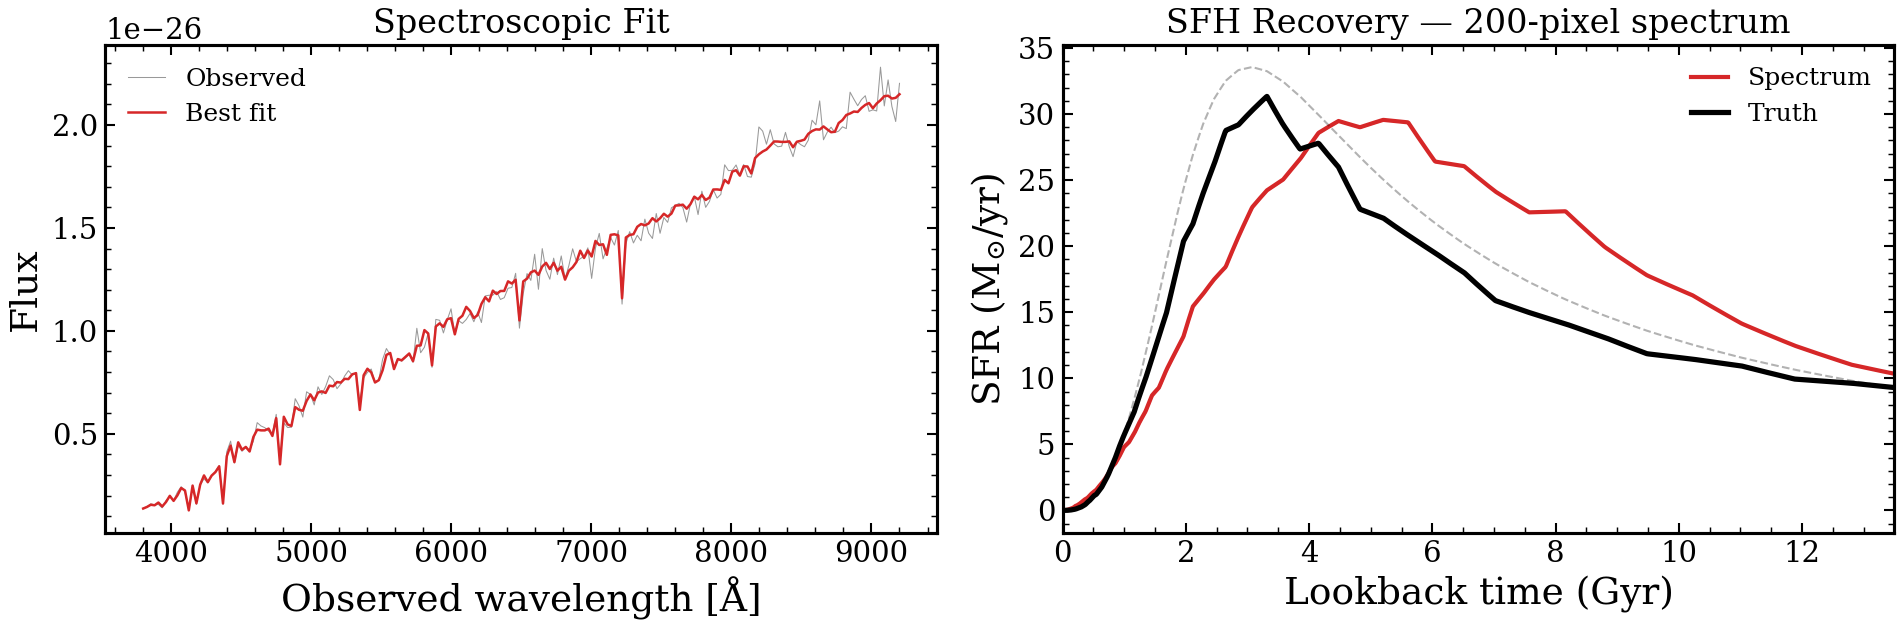

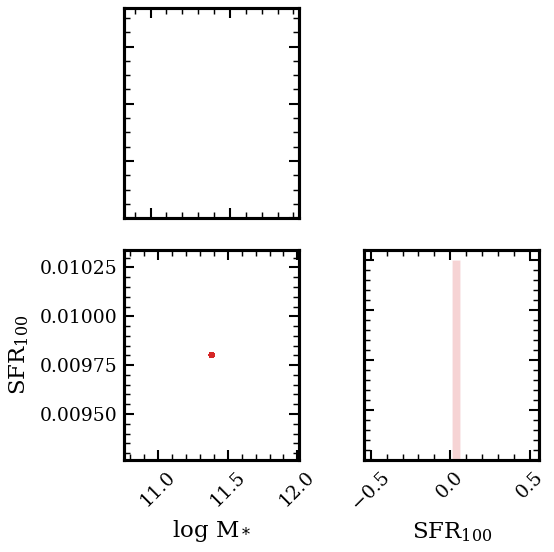

In [8]:
# Generate a mock spectrum (200 pixels, SNR=30)
wave_obs = jnp.linspace(3800.0, 9200.0, 200)
spec_true = model_full.predict_spectrum(true_params, wave_obs)
noise_spec = spec_true / 30.0  # SNR = 30
key_spec = jax.random.PRNGKey(99)
spec_obs = spec_true + noise_spec * jax.random.normal(key_spec, spec_true.shape)

# Attach wavelength grid to model for spectroscopic fitting
model_full._wave_obs = wave_obs

result_spec = run_fit(model_full, spec_obs, noise_spec, "spectrum",
                      data_type="spectroscopy")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Show the spectrum with fit
ax_spec = axes[0]
ax_spec.plot(wave_obs, spec_obs, color="0.6", lw=0.5, label="Observed")
pred_spec = model_full.predict_spectrum(result_spec.params, wave_obs)
ax_spec.plot(wave_obs, pred_spec, color=STAGE_COLORS["spectrum"],
             lw=1.2, label="Best fit")
ax_spec.set_xlabel("Observed wavelength [\u00c5]")
ax_spec.set_ylabel("Flux")
ax_spec.set_title("Spectroscopic Fit")
ax_spec.legend()

# SFH recovery
model_full.plot_sfh_posterior(result_spec, true_params=true_params,
                             color=STAGE_COLORS["spectrum"],
                             label="Spectrum", ax=axes[1])
axes[1].set_title("SFH Recovery — 200-pixel spectrum")
axes[1].legend()

plt.tight_layout()
plt.show()

fig_corner_spec = safe_corner(result_spec, truths=true_params,
                               color=STAGE_COLORS["spectrum"],
                               label="Spectrum")
plt.show()

## Joint Photometry + Spectroscopy

Combining both data types: photometry anchors the absolute SED
shape (broad wavelength baseline, calibrated fluxes), while
spectroscopy resolves individual features.  The result is the
tightest possible constraints.

  Step     0/1000: loss = 50982.8229


  Step   200/1000: loss = 126.3733


  Step   400/1000: loss = 120.3666


  Step   600/1000: loss = 114.4982


  Step   800/1000: loss = 108.9090


  Step   999/1000: loss = 102.5380
  MAP (ADAM) complete in 2.7s, 1000 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.6s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 300
joint (phot+spec): fit completed in 10.0s


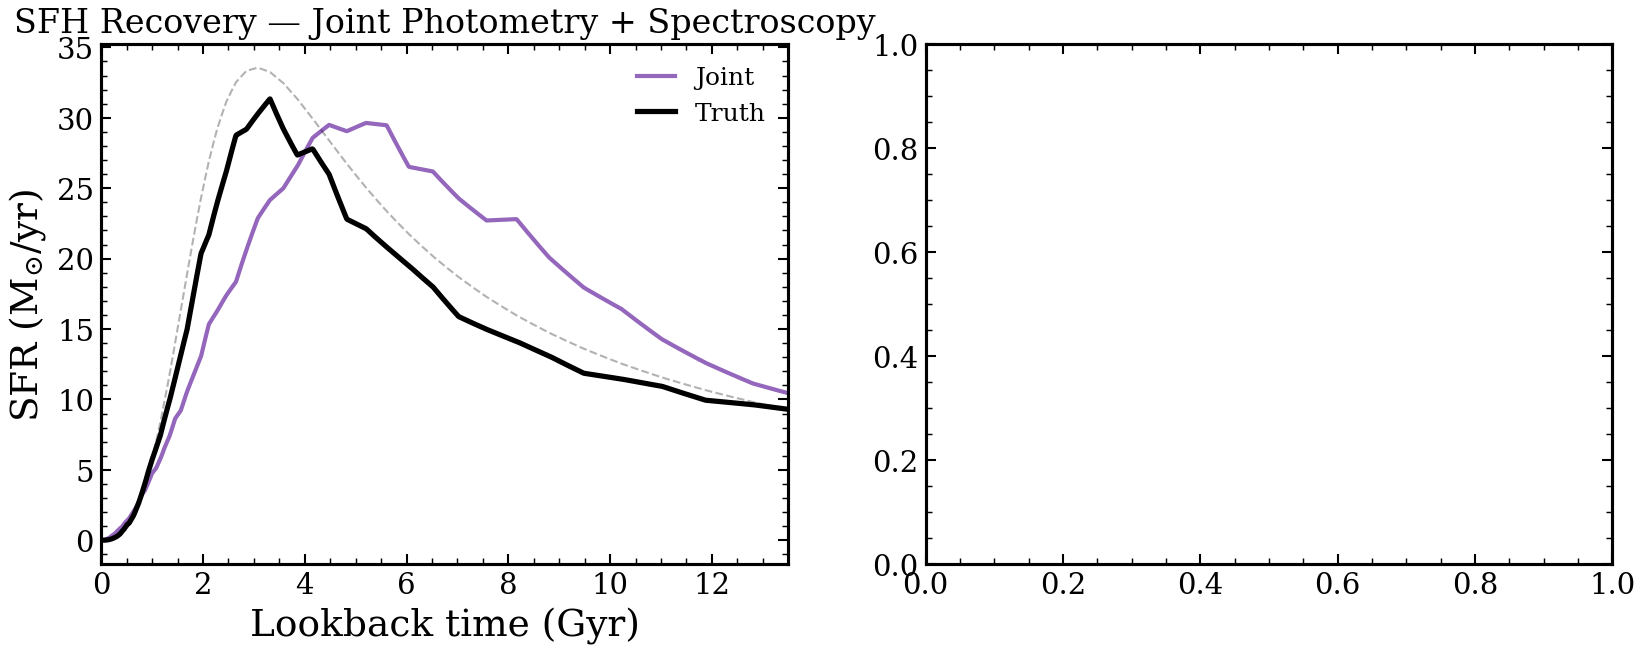

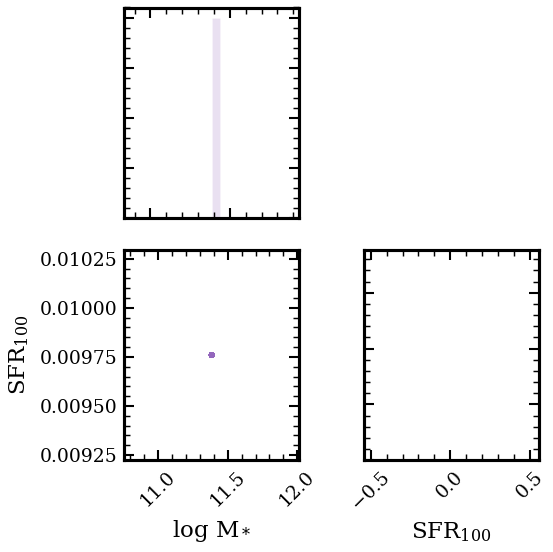

In [9]:
# Joint data vector: photometry (5 bands) + spectrum (200 pixels)
joint_data = jnp.concatenate([mock_full.flux_obs, spec_obs])
joint_noise = jnp.concatenate([mock_full.noise, noise_spec])

result_joint = run_fit(model_full, joint_data, joint_noise,
                       "joint (phot+spec)", data_type="joint")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

model_full.plot_sfh_posterior(result_joint, true_params=true_params,
                             color="C4", label="Joint", ax=axes[0])
axes[0].set_title("SFH Recovery — Joint Photometry + Spectroscopy")
axes[0].legend()

fig_corner_joint = safe_corner(result_joint, truths=true_params,
                                color="C4", label="Joint")
plt.show()

## The Progressive Reveal

All stages side by side — the visual progression from near-ignorance
to tight recovery.

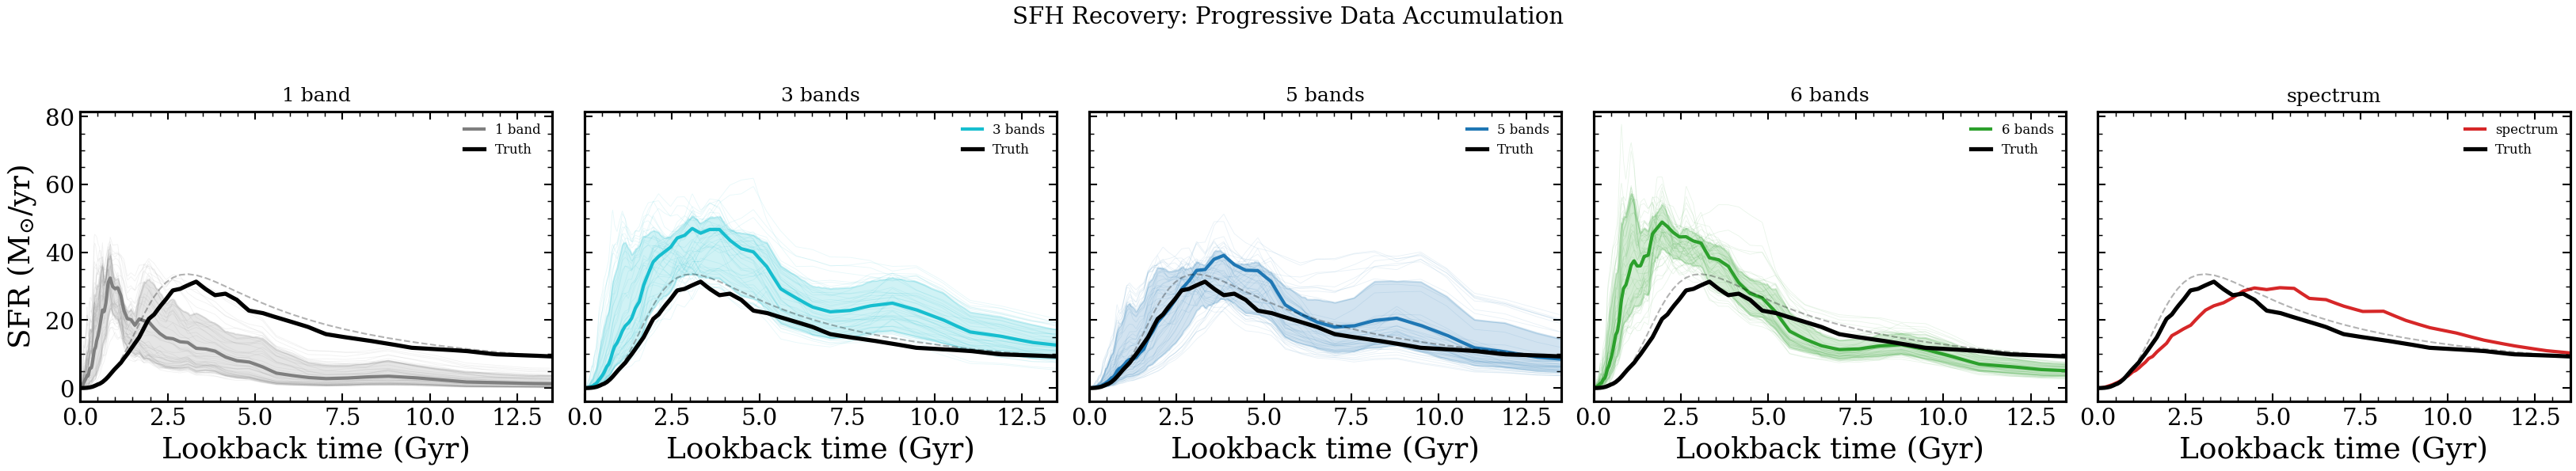

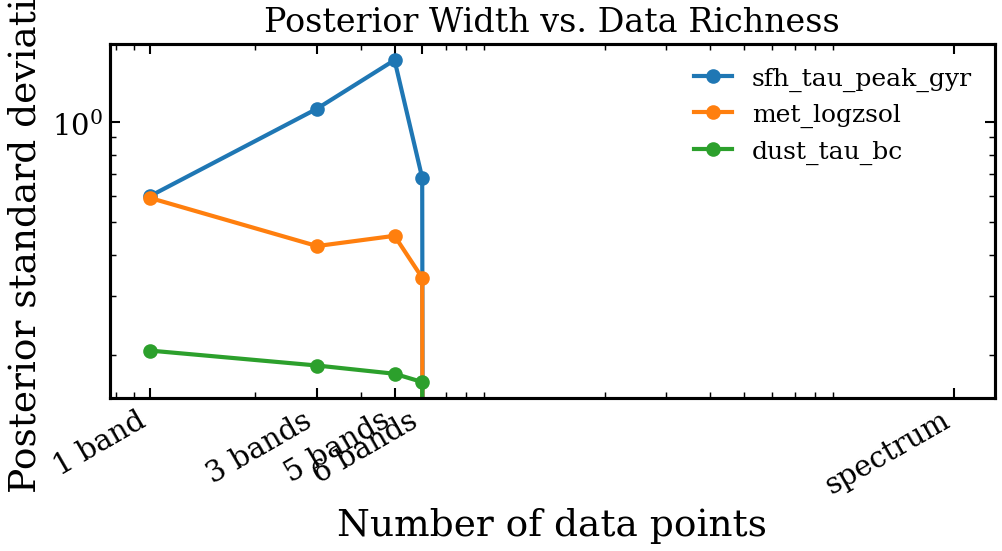

In [10]:
# Collect all results
all_results = {
    "1 band":   result_1band,
    "3 bands":  result_3band,
    "5 bands":  result_5band,
    "6 bands":  result_6band,
    "spectrum": result_spec,
}
all_models = {
    "1 band":   model_1,
    "3 bands":  model_3,
    "5 bands":  model_full,
    "6 bands":  model_6,
    "spectrum": model_full,
}

# --- Panel 1: SFH recovery across all stages ---
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)

for ax, (label, result) in zip(axes, all_results.items()):
    m = all_models[label]
    m.plot_sfh_posterior(result, true_params=true_params,
                        color=STAGE_COLORS[label], label=label, ax=ax)
    ax.set_title(label, fontsize=12)
    if ax != axes[0]:
        ax.set_ylabel("")
    ax.legend(fontsize=8)

fig.suptitle("SFH Recovery: Progressive Data Accumulation",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Panel 2: Posterior width summary ---
fig, ax = plt.subplots(figsize=(7, 4))

labels = list(all_results.keys())
n_data = [1, 3, 5, 6, 200]
colors = [STAGE_COLORS[l] for l in labels]

# Compute posterior spread for key parameters
key_params = ["sfh_tau_peak_gyr", "met_logzsol", "dust_tau_bc"]
for i, pname in enumerate(key_params):
    widths = []
    for label in labels:
        summary = all_results[label].summary()
        if pname in summary:
            s = summary[pname]
            if 'hi_68' in s and 'lo_68' in s:
                widths.append((s['hi_68'] - s['lo_68']) / 2)
            else:
                widths.append(np.nan)
        else:
            widths.append(np.nan)
    ax.plot(n_data, widths, "o-", label=pname, color=f"C{i}")

ax.set_xlabel("Number of data points")
ax.set_ylabel("Posterior standard deviation")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(n_data)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.legend()
ax.set_title("Posterior Width vs. Data Richness")
plt.tight_layout()
plt.show()

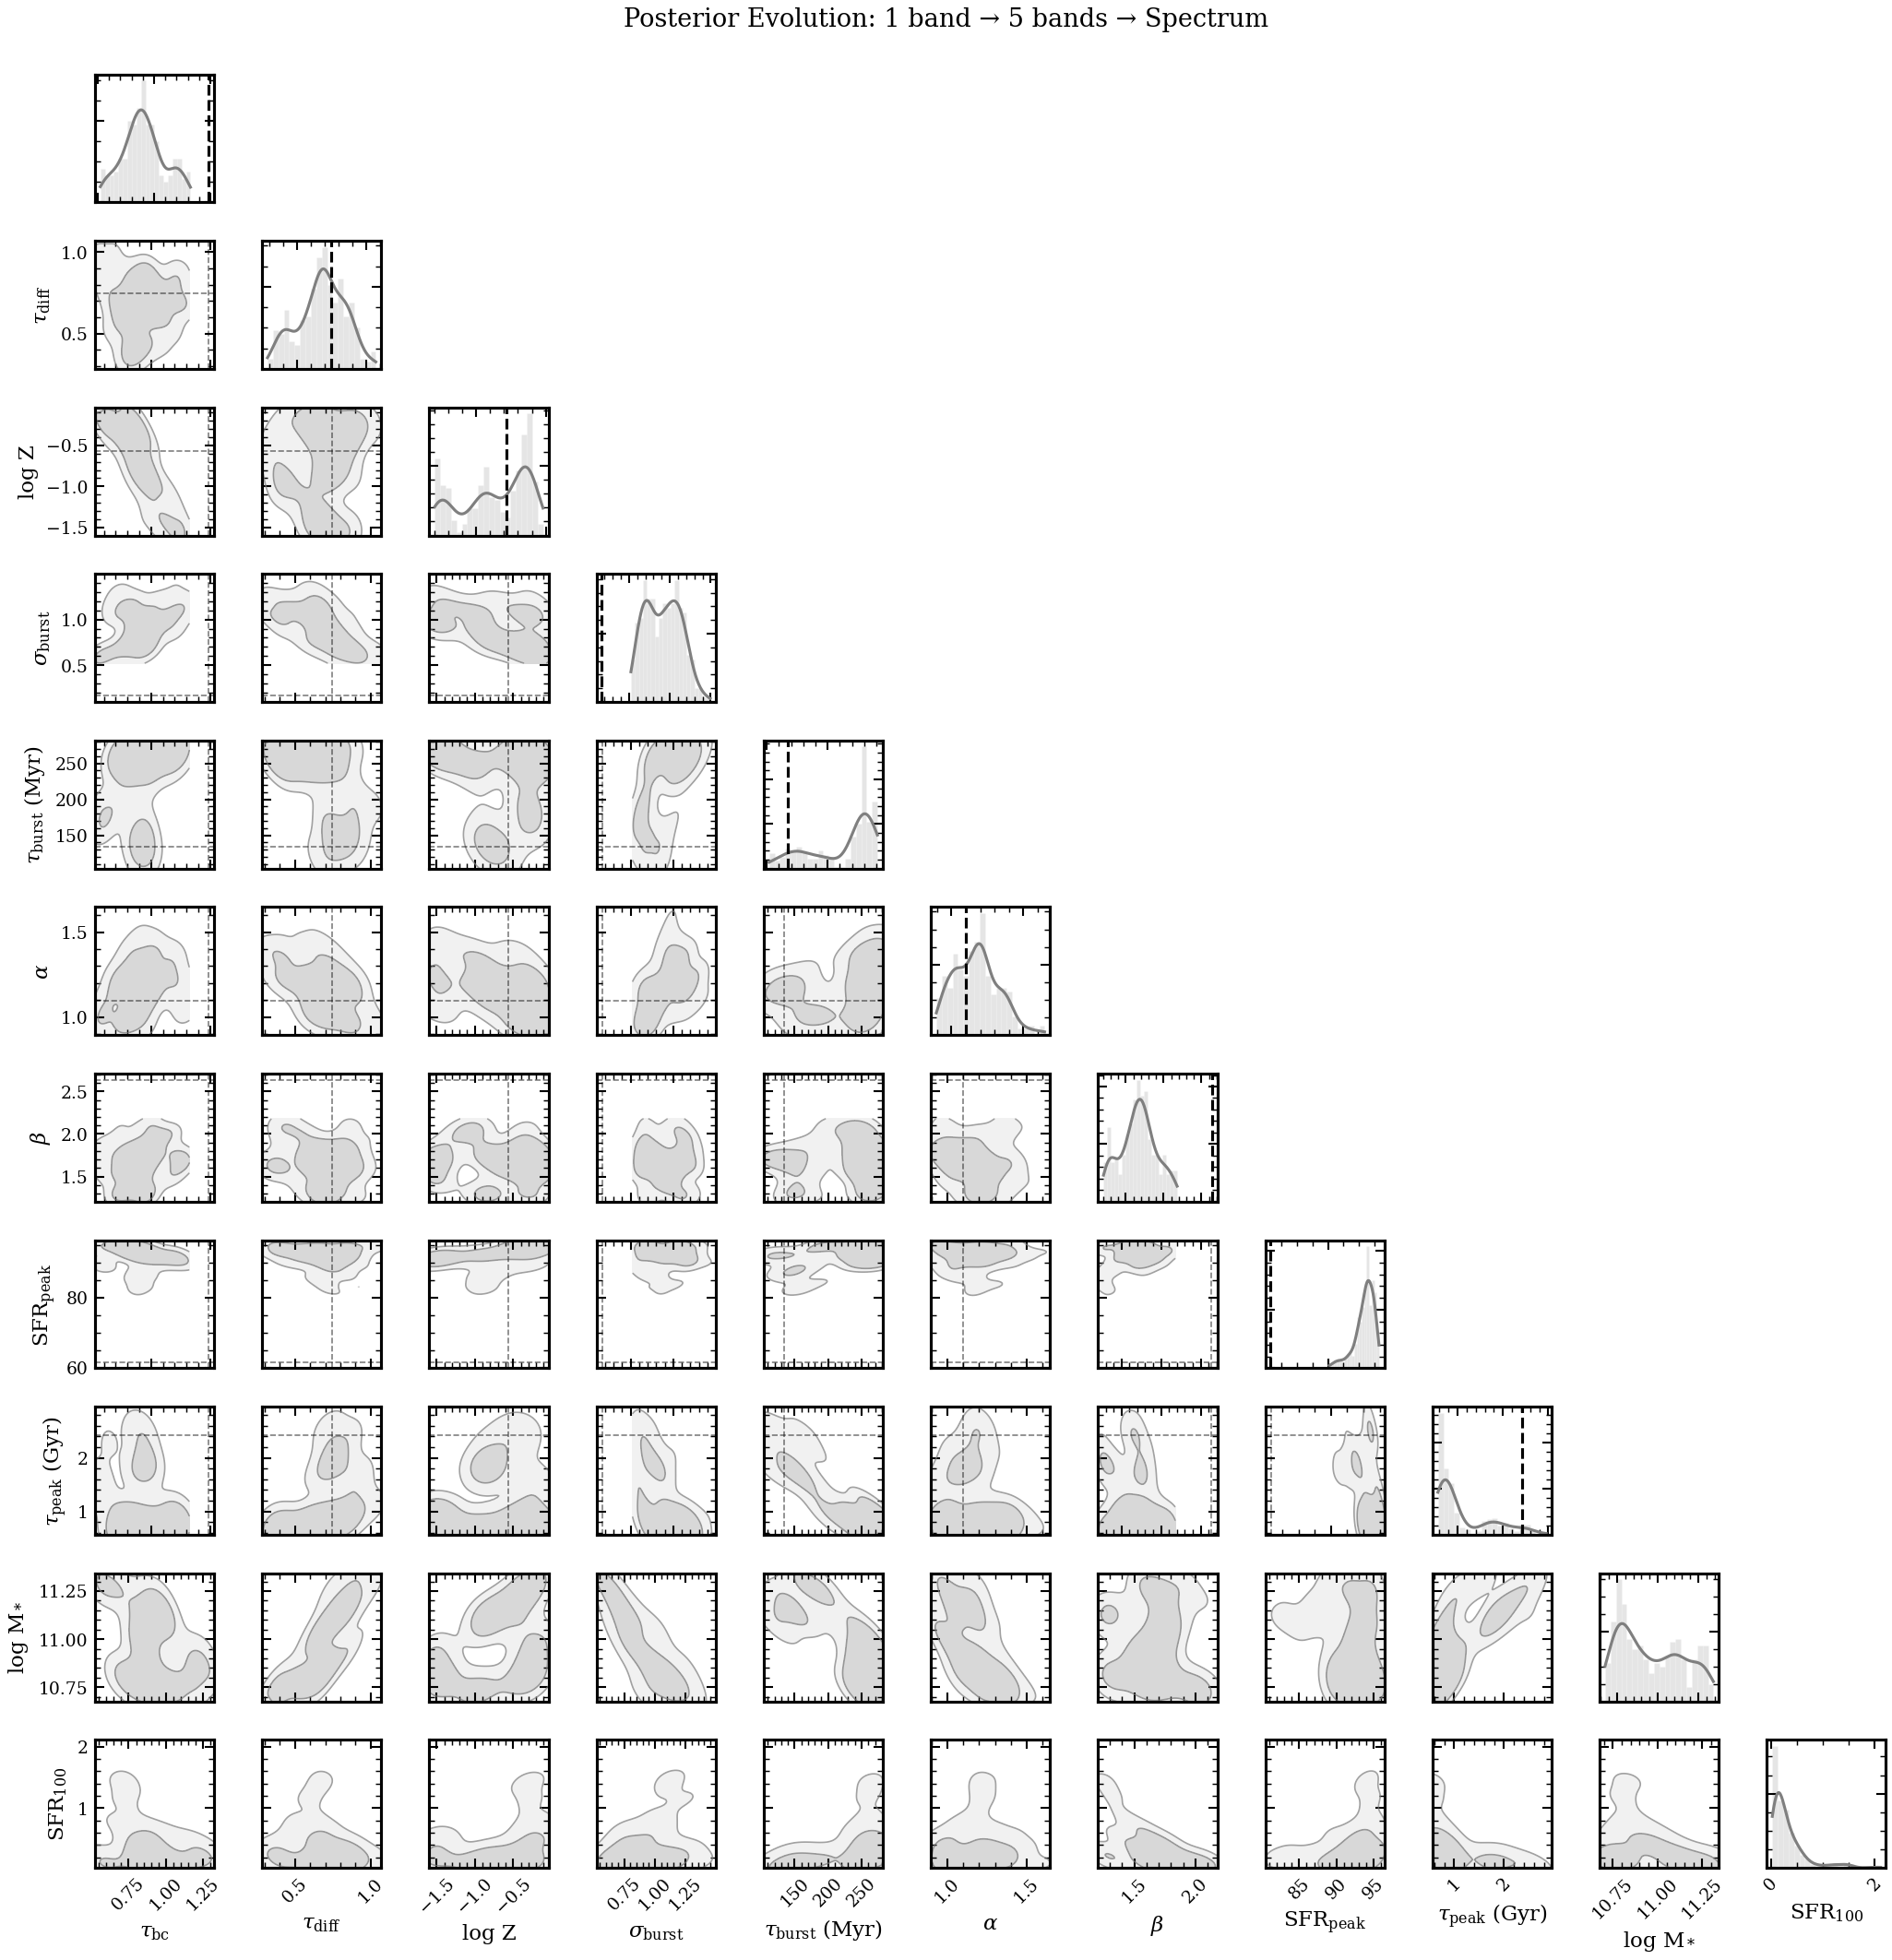

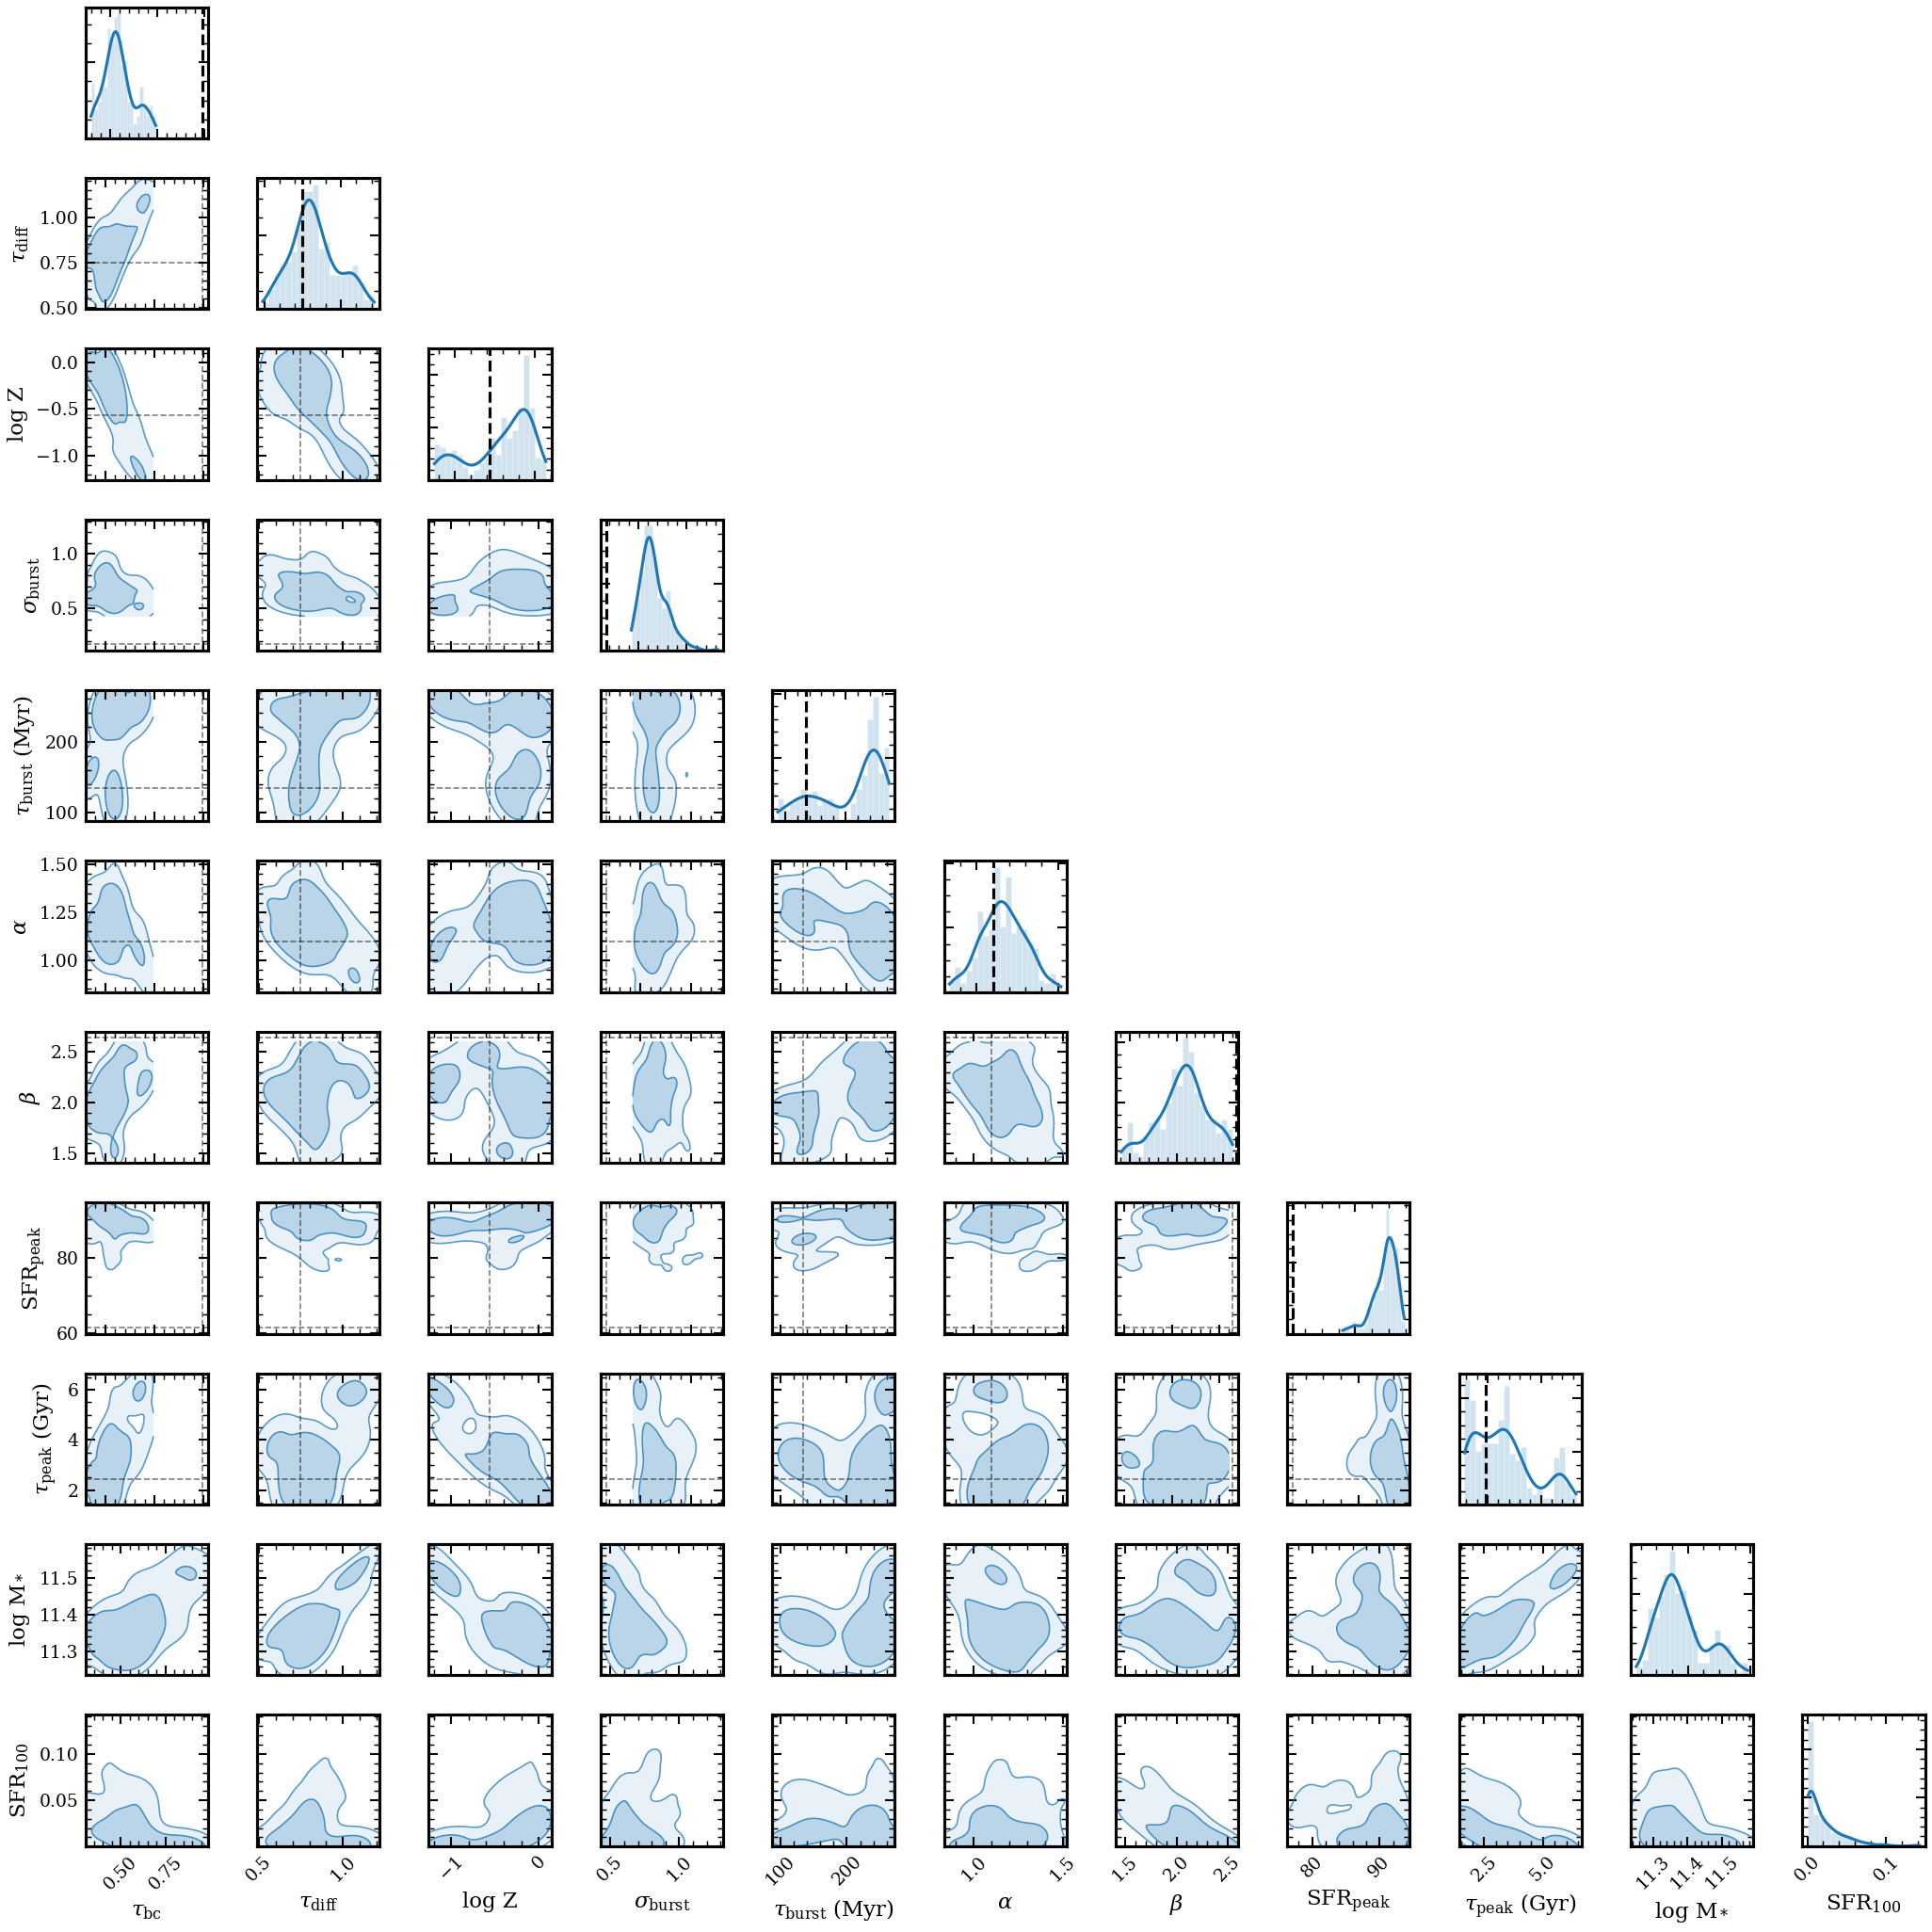

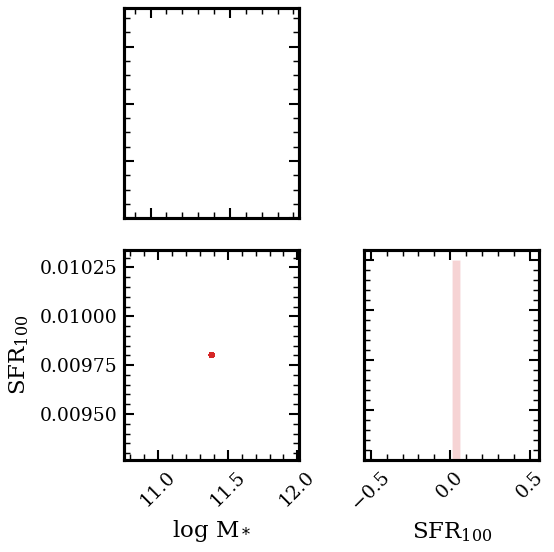

In [11]:
# Overlay corner plots: 1-band (broad), 5-band (medium), spectrum (tight)
fig = safe_corner(result_1band, truths=true_params,
                  color=STAGE_COLORS["1 band"],
                  label="1 band")
if fig is not None:
    safe_corner(result_5band, truths=true_params,
                color=STAGE_COLORS["5 bands"],
                label="5 bands", fig=fig)
    safe_corner(result_spec, truths=true_params,
                color=STAGE_COLORS["spectrum"],
                label="Spectrum", fig=fig)
fig.suptitle("Posterior Evolution: 1 band → 5 bands → Spectrum",
             fontsize=13, y=1.02)
plt.show()

## What About Burstiness Parameters?

The PSD parameters $\sigma_{\rm PSD}$ (burstiness amplitude) and
$\tau_{\rm PSD}$ (correlation timescale) are the hardest to
constrain.  Photometry constrains $\sigma$ (it affects overall SED
shape) but poorly constrains $\tau$ (timescale information is
washed out in broadband fluxes).

Spectroscopy helps with $\tau$ because individual spectral features
have intrinsic temporal sensitivity — Balmer lines respond on
$\sim 100$ Myr timescales, while the 4000 Å break responds on
$\sim 1$ Gyr timescales.

This motivates **hierarchical inference** (NB05), where shared PSD
priors across a galaxy sample pool information to constrain what
individual fits cannot.

Corner plot skipped: Contour levels must be increasing
Corner plot skipped: Contour levels must be increasing


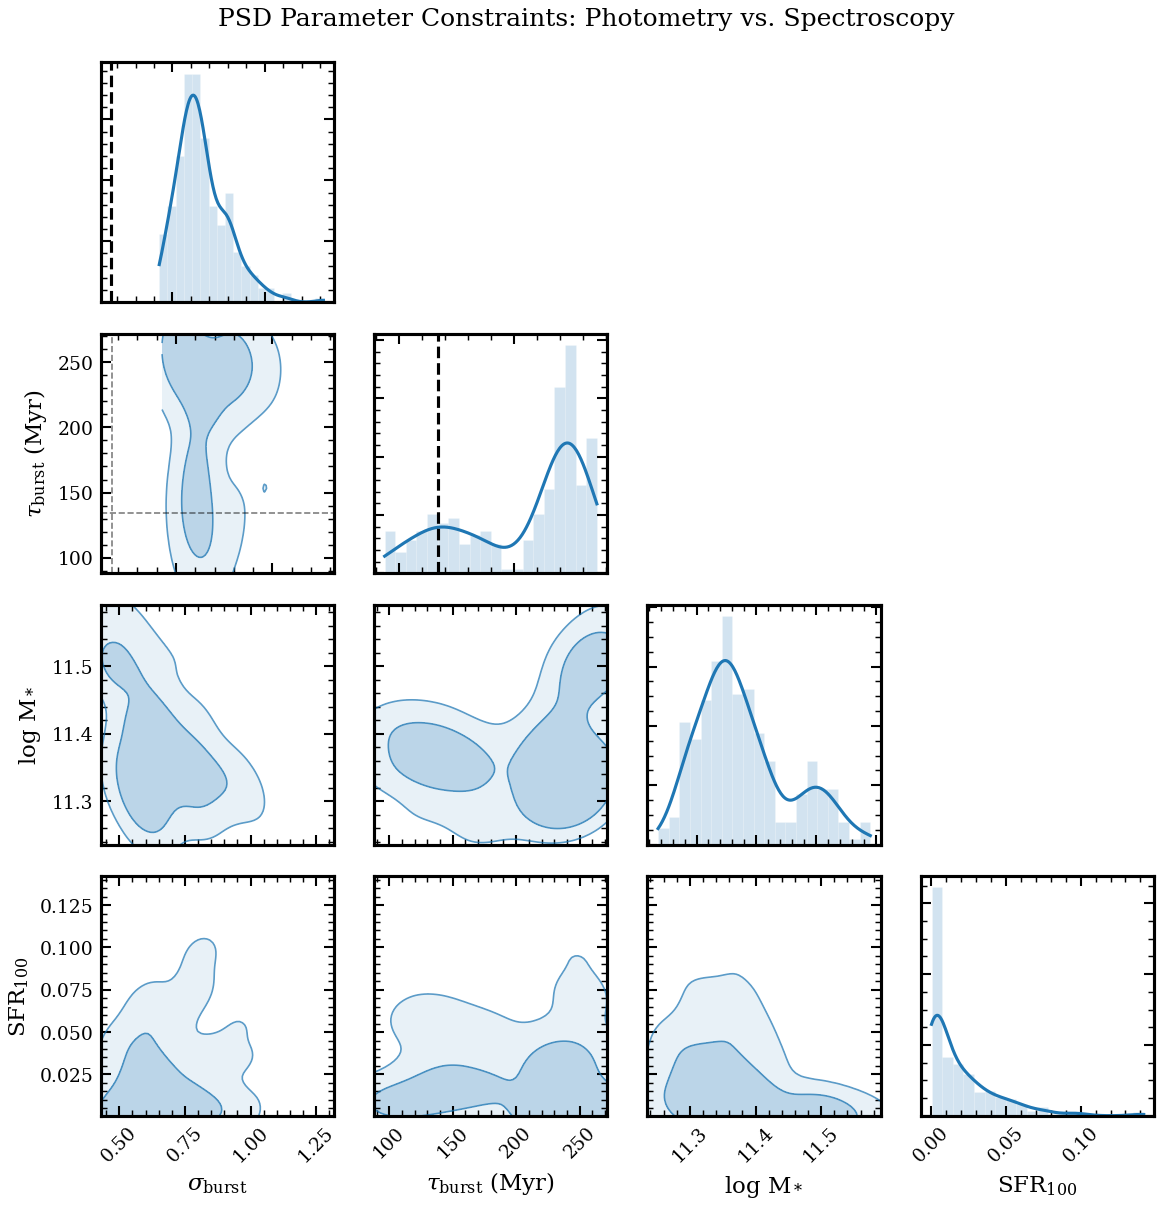

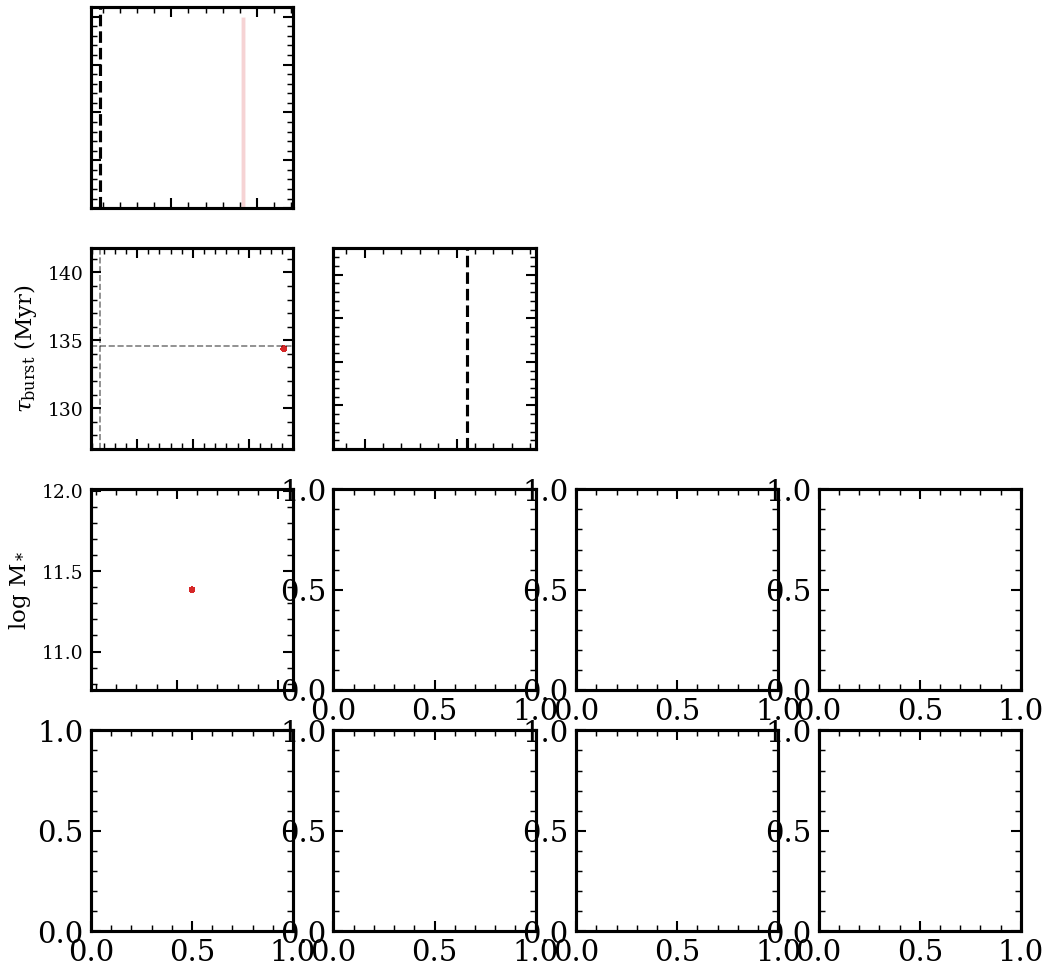

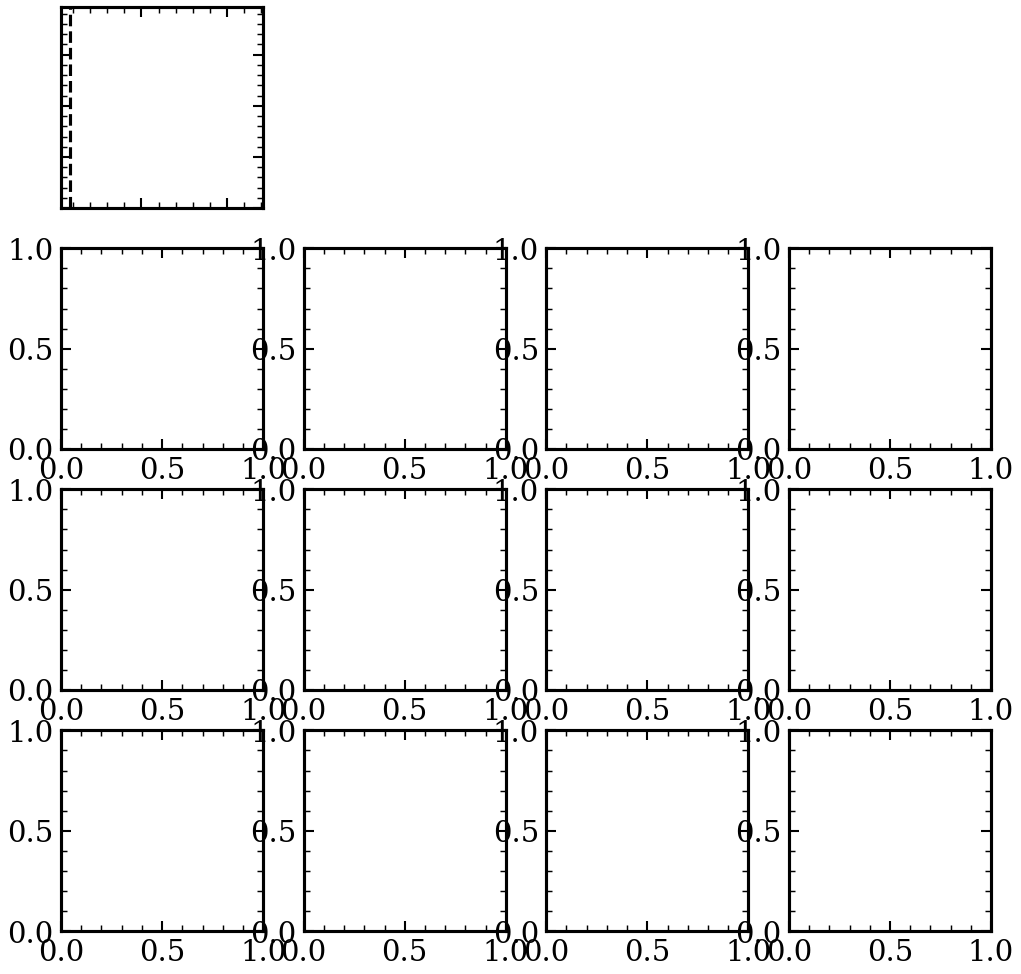

In [12]:
# Corner plot of just (psd_sigma, psd_tau_myr): photometry vs spectroscopy
psd_params = ["psd_sigma", "psd_tau_myr"]

fig = safe_corner(result_5band, params=psd_params, truths=true_params,
                  color=STAGE_COLORS["5 bands"],
                  label="5-band photometry")
if fig is not None:
    safe_corner(result_spec, params=psd_params, truths=true_params,
                color=STAGE_COLORS["spectrum"],
                label="Spectrum", fig=fig)
    safe_corner(result_joint, params=psd_params, truths=true_params,
                color="C4", label="Joint", fig=fig)
fig.suptitle("PSD Parameter Constraints: Photometry vs. Spectroscopy",
             fontsize=12, y=1.02)
plt.show()

## Practical Guidance

| Survey | Typical bands | Well constrained | Poorly constrained |
|--------|---------------|------------------|--------------------|
| SDSS (phot) | ugriz (5) | Stellar mass, mean age, $A_V$ | Burst timing, $\tau_{\rm PSD}$, metallicity |
| DESI (spec) | 3600--9800 Å | Age, metallicity, recent SFH, dust | PSD timescale (still degenerate) |
| JWST (phot) | F115W--F444W (6+) | Stellar mass to $z \sim 10$, dust | Detailed SFH at high-$z$ |
| Euclid + ground | $ugrizYJH$ (8+) | Photo-$z$, mass, broad SFH | Burstiness, line features |

**Rules of thumb:**
- For catalog-scale work with photometry only, parametric SFH models
  may suffice (and are much cheaper).
- For recovering bursty, non-parametric SFHs, spectroscopy makes a
  **qualitative** difference — not just quantitative.
- Hierarchical inference (shared PSD priors across a sample) is the
  key to constraining burstiness from photometry alone.

## Next Steps

- **[NB04 — SFH Recovery Tests](04_sfh_recovery.ipynb)**: Systematic
  mock recovery benchmarks across parameter space
- **[NB05 — Hierarchical Inference](05_hierarchical.ipynb)**: Shared
  PSD priors that pool information across galaxy samples
- **[NB07 — Spectroscopic Fitting](07_spectroscopy.ipynb)**: Deep
  dive into spectral fitting, line diagnostics, and joint modelling